<a href="https://colab.research.google.com/github/Nois12/AIFFEL_quest_rs/blob/main/GoingDeeper/Gd06/Korean_Chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformer 기반 한국어 챗봇 — 수정본
정제·질문 그룹 분할 → Train만 30,000쌍 증강 → 모델 비교 → 최적 체크포인트 → 동일 Test 평가

## 실행 흐름
1. 원본 EDA와 결측치 처리, Q–A 쌍 중복 제거, 길이 필터링
2. 정규화한 질문 그룹으로 Train/Val/Test 분할 및 겹침 검사
3. Train 질문에만 보수적인 대화 표현을 추가하여 고유 Q–A 30,000쌍 구성
4. Train만으로 단어 사전·출력 복원용 품사 사전 구축
5. 모델 크기·Dropout·Warmup, Attention 3종 × 구조 2종 비교
6. 최종 구성 재검증, 최적 에폭의 가중치 복원 및 학습 곡선 표시
7. Val에서 디코딩 전략 선택, 예문 출력, Test 전체에서 BLEU·빈 답변 비율 비교

## 개선사항 (수정내용) - 이 부분에서 ai의 도움을 엄청 많이 받은 프로젝트다......
- 답변 중복만으로 유효한 질문을 삭제하지 않았다. 질문 그룹을 분리해 데이터 누출을 검사했다.
- 의미가 불확실한 Word2Vec 치환과 답변 증강을 제거했다. 대화 표현 추가는 의미 보존을 우선했다.
- 빈 답변은 BLEU 0점으로 포함했고, 긴 질문은 학습 길이로 잘라 답변 공간을 확보했다.
- 사용자용 문장 복원과 평가용 형태소 출력을 분리했다.
- 공통 Encoder–Decoder 구현과 공통 BLEU 평가를 사용했다. 같은 학습 설정은 최적 체크포인트를 재사용했다.
- 최적 에폭의 Train/Val Loss를 함께 표시했다. Test 결과는 모델 선택에 다시 사용하지 않았다.
- 시드 추가, 비교실험 추가
-> 비교실험을 추가함으로 인해 프로젝트 완성까지의 시간이 많이 소요되었다...

## 환경 설정

In [ ]:
# Google Colab 설치 셀. 로컬 환경에서는 필요한 패키지를 환경에 맞게 설치해야 한다.
%pip install -q kiwipiepy==0.23.2 nltk==3.9.1 pandas matplotlib tqdm

try:
    import matplotlib
    import matplotlib.pyplot as plt
    import matplotlib.font_manager as fm
    from pathlib import Path
    !apt-get -qq -y install fonts-nanum > /dev/null 2>&1
    font_path = Path('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    if font_path.exists():
        fm.fontManager.addfont(str(font_path))
        plt.rcParams['font.family'] = 'NanumGothic'
        matplotlib.rcParams['axes.unicode_minus'] = False
except Exception as e:
    print('[폰트 설정 생략]', e)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 32.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 164.2 MB/s eta 0:00:00


## 라이브러리 불러오기 & 공통 유틸

In [ ]:
import re
import urllib.request
import copy
import random
import math
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from kiwipiepy import Kiwi
from functools import wraps
from pathlib import Path
import hashlib
import json

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 형태소 분석은 Kiwi 사용 (morphs 인터페이스)
class KoreanTokenizer:
    def __init__(self):
        self._kiwi = Kiwi()

    def morphs(self, text):
        return [token.form for token in self._kiwi.tokenize(text)]

tokenizer = KoreanTokenizer()

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(torch.__version__, "| device:", device)

def pad_sequences_custom(sequences, max_len=50, pad_value=0):
    """
    sequences: list of list (각 문장별 토큰 ID 리스트)
    max_len: 고정할 최대 시퀀스 길이
    pad_value: 패딩에 사용할 값 (일반적으로 0)
    """
    padded_sequences = []
    for seq in sequences:
        if len(seq) > max_len:
            seq = seq[:max_len]
        else:
            seq = seq + [pad_value] * (max_len - len(seq))
        padded_sequences.append(seq)

    return torch.tensor(padded_sequences, dtype=torch.long)

2.11.0+cu128 | device: cuda


## Transformer 모델 구성


In [ ]:
# Positional Encoding
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table

# 패딩 마스크 / 룩어헤드 마스크
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()

def generate_lookahead_mask(size: int) -> torch.Tensor:
    return torch.triu(torch.ones(size, size), diagonal=1)

def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    enc_mask = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(src)

    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])
    dec_tgt_padding_mask = generate_padding_mask(tgt)
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

# Multi-Head Attention
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        QK = torch.matmul(Q, K.transpose(-1, -2))
        scaled_qk = QK / math.sqrt(d_k)

        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)
        return out, attentions

    def split_heads(self, x):
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        return x.view(bsz, seq_len, self.d_model)

    def forward(self, Q, K, V, mask=None):
        WQ, WK, WV = self.W_q(Q), self.W_k(K), self.W_v(V)
        WQ_splits, WK_splits, WV_splits = self.split_heads(WQ), self.split_heads(WK), self.split_heads(WV)

        out, attention_weights = self.scaled_dot_product_attention(WQ_splits, WK_splits, WV_splits, mask)

        out = self.combine_heads(out)
        out = self.linear(out)
        return out, attention_weights

# Position-wise Feed Forward Network
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))
        out = self.fc2(out)
        return out

# Learning Rate Scheduler / Loss / Train Step
class LearningRateScheduler:
    def __init__(self, warmup_steps=4000, peak_lr=3e-4):
        self.warmup_steps = warmup_steps
        self.peak_lr = peak_lr

    def __call__(self, step):
        step = float(max(step, 1))
        return self.peak_lr * min(step / self.warmup_steps, math.sqrt(self.warmup_steps / step))


def loss_function(real, pred):
    real = real.to(device)
    pred = pred.to(device)

    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), reduction='none')
    loss_ = loss_.view(real.size())

    mask = (real != 0).float()
    loss_ = loss_ * mask

    return loss_.sum() / mask.sum()


def train_step(src, tgt, model, optimizer):
    model.train()
    optimizer.zero_grad()

    tgt_in = tgt[:, :-1]
    gold = tgt[:, 1:]

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src = src.to(device)
    tgt_in = tgt_in.to(device)
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    loss = loss_function(gold, predictions)
    if not torch.isfinite(loss):
        raise FloatingPointError("loss가 유한하지 않습니다 (NaN/Inf). 학습률/데이터를 확인하세요.")

    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # 그레디언트 폭주 방지
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns


def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    return sentence_bleu([reference], candidate, weights=weights,
                         smoothing_function=SmoothingFunction().method1)

# Attention 클래스를 받는 공통 Encoder–Decoder 구현
class GenEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout, attn_cls=MultiHeadAttention, attn_kwargs=None):
        super().__init__()
        attn_kwargs = attn_kwargs or {}
        self.enc_self_attn = attn_cls(d_model, n_heads, **attn_kwargs)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual

        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual
        return out, enc_attn


class GenDecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout, attn_cls=MultiHeadAttention, attn_kwargs=None):
        super().__init__()
        attn_kwargs = attn_kwargs or {}
        self.dec_self_attn = attn_cls(d_model, n_heads, **attn_kwargs)
        self.enc_dec_attn = attn_cls(d_model, n_heads, **attn_kwargs)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual
        return out, dec_attn, dec_enc_attn


class GenEncoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout, attn_cls=MultiHeadAttention, attn_kwargs=None):
        super().__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [GenEncoderLayer(d_model, n_heads, d_ff, dropout, attn_cls, attn_kwargs) for _ in range(n_layers)]
        )

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns


class GenDecoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout, attn_cls=MultiHeadAttention, attn_kwargs=None):
        super().__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [GenDecoderLayer(d_model, n_heads, d_ff, dropout, attn_cls, attn_kwargs) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns, dec_enc_attns = [], []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns


class GenTransformer(nn.Module):

    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_emb=True, attn_cls=MultiHeadAttention, attn_kwargs=None):
        super().__init__()
        self.d_model = float(d_model)

        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=0)

        pos_encoding_np = positional_encoding(pos_len, d_model)
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)
        self.encoder = GenEncoder(n_layers, d_model, n_heads, d_ff, dropout, attn_cls, attn_kwargs)
        self.decoder = GenDecoder(n_layers, d_model, n_heads, d_ff, dropout, attn_cls, attn_kwargs)
        self.enc_final_norm = nn.LayerNorm(d_model)
        self.dec_final_norm = nn.LayerNorm(d_model)
        self.fc = nn.Linear(d_model, tgt_vocab_size)

        for parameter in self.parameters():
            if parameter.ndim > 1:
                nn.init.xavier_uniform_(parameter)
        nn.init.normal_(self.enc_emb.weight, std=d_model ** -0.5)
        if self.dec_emb is not self.enc_emb:
            nn.init.normal_(self.dec_emb.weight, std=d_model ** -0.5)
        with torch.no_grad():
            self.enc_emb.weight[0].zero_()
            self.dec_emb.weight[0].zero_()
        nn.init.zeros_(self.fc.bias)

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)
        out = out * math.sqrt(self.d_model)
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        enc_out = self.enc_final_norm(enc_out)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)
        dec_out = self.dec_final_norm(dec_out)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

## 하이퍼파라미터 정리


In [ ]:
CONFIG = {
    "max_tokens": 25,              # Step 3: 토큰 길이 제한 (이보다 길면 데이터에서 제외)
    "batch_size": 64,              # Step 6: 학습 배치 크기

    "n_heads": 8,                  # Step 6: Transformer 헤드 수 (비교실험 대상 아님, 고정값)

    "experiment_max_epochs": 30,   # Step 6: 비교실험용 최대 에폭 (Early Stopping이 실제 종료 시점을 결정)
    "max_epochs": 200,             # Step 6: 최종 훈련 최대 에폭 (Early Stopping이 실제 종료 시점을 결정)

    "val_ratio": 0.1,              # Step 3: 검증 데이터 비율 (Augmentation 이전에 분리)
    "test_ratio": 0.1,             # Step 3: 테스트 데이터 비율 (Step 7에서 딱 한 번만 사용)
    "early_stopping_patience": 5,  # Step 6: 검증 loss가 이 에폭 수만큼 연속 개선 안 되면 조기 종료

    "experiment_eval_size": 100,   # Step 6: 비교실험 단계에서 사용할 평가 문장 수 (검증셋 기준)
    "final_eval_size": None,        # None이면 필터링된 Test 전체를 같은 순서로 평가

    "base_dropout": 0.2,           # Step 6: 모델 크기 실험 시 고정할 dropout
    "base_warmup": 1000,           # Step 6: 모델 크기/Dropout 실험 시 고정할 warmup_steps
    "peak_lr": 3e-4,               # Step 6: 학습률 스케줄의 최대값
    "beam_size": 3,                # Step 6: Beam Search 빔 크기
    "no_repeat_ngram_size": 3,     # Step 6: 디코딩 시 이미 나온 n-gram 반복 차단 (n=3)
    "target_train_pairs": 30000,  # 고유 Q–A 쌍 기준
    "seed": 42,                    # 재현성 및 공정한 비교실험을 위한 랜덤 시드

    "size_candidates": [           # Step 6 실험 1: 모델 크기 후보
        {"name": "n1_d368", "n_layers": 1, "d_model": 368, "d_ff": 1024},
        {"name": "n2_d512", "n_layers": 2, "d_model": 512, "d_ff": 2048},
    ],
    "dropout_candidates": [0.1, 0.2, 0.3],  # Step 6 실험 2
    "warmup_candidates": [1000, 4000],      # Step 6 실험 3
}

# Step 1. 데이터 다운로드


In [ ]:
csv_url = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
csv_filename = "ChatbotData.csv"
urllib.request.urlretrieve(csv_url, csv_filename)

chatbot_data = pd.read_csv(csv_filename)
chatbot_data = chatbot_data.dropna(subset=["Q", "A"]).copy()
questions = chatbot_data['Q'].tolist()
answers = chatbot_data['A'].tolist()

print("데이터 개수:", len(questions))
for q, a in list(zip(questions, answers))[:3]:
    print(">> Q:", q, "| A:", a)

데이터 개수: 11823
>> Q: 12시 땡! | A: 하루가 또 가네요.
>> Q: 1지망 학교 떨어졌어 | A: 위로해 드립니다.
>> Q: 3박4일 놀러가고 싶다 | A: 여행은 언제나 좋죠.


# Step 1-2. 탐색적 데이터 분석 (EDA)
정제/토큰화 전에 원본 데이터를 확인했다.

결측치, 중복, 라벨 분포, 문장 길이 분포를 보고 뒤에서 쓰는 max_tokens=25 같은 설정이 데이터 특성에 맞는지 확인했다.

데이터 shape: (11823, 3)
컬럼: ['Q', 'A', 'label']

결측치:
Q        0
A        0
label    0
dtype: int64

Q 중복 개수: 161
A 중복 개수: 4044

라벨 분포:
  0 (일상다반사) : 5290개 (44.7%)
  1 (이별(부정)) : 3570개 (30.2%)
  2 (사랑(긍정)) : 2963개 (25.1%)


,Q,A,label
8169,죽을거 같네,나쁜 생각 하지 마세요.,1
900,내일 시험이야,컨디션 조절 하세요.,0
8075,정말.내 자신이 싫다,자신은 사랑해주세요.,1
7625,이별후 네달째,바쁘게 살면서 잊어가요.,1
2816,쌍커풀 해볼까,눈은 기본이죠.,0


Q 형태소 개수: 평균 7.9, 최대 31, 25 초과 비율 0.1%
A 형태소 개수: 평균 9.6, 최대 45, 25 초과 비율 0.5%


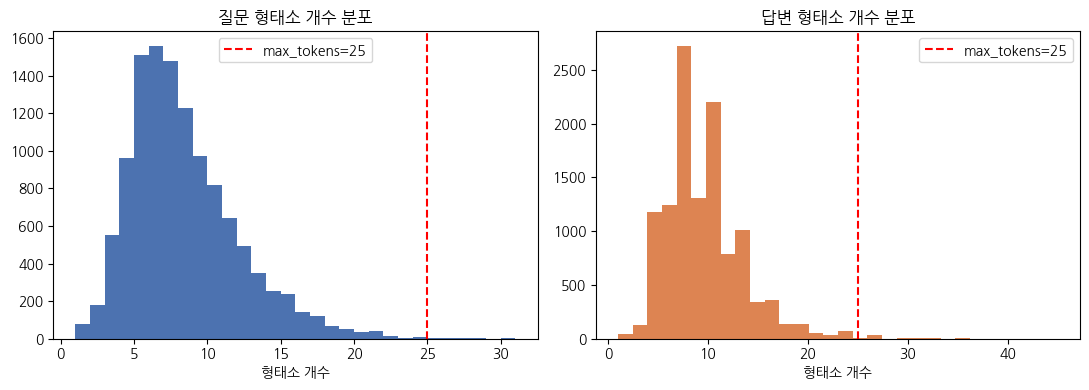

자주 등장하는 형태소 Top 15:
  .: 13906
  하: 10361
  이: 9755
  어: 9065
  는: 4601
  어요: 3858
  보: 3628
  었: 3278
  세요: 3165
  ᆯ: 3150
  ᆫ: 3137
  을: 3048
  가: 3042
  거: 2948
  지: 2509


In [ ]:
print("데이터 shape:", chatbot_data.shape)
print("컬럼:", list(chatbot_data.columns))
print()
print("결측치:")
print(chatbot_data.isnull().sum())
print()
print("Q 중복 개수:", chatbot_data["Q"].duplicated().sum())
print("A 중복 개수:", chatbot_data["A"].duplicated().sum())

if "label" in chatbot_data.columns:
    label_map = {0: "일상다반사", 1: "이별(부정)", 2: "사랑(긍정)"}
    label_counts = chatbot_data["label"].value_counts().sort_index()
    print()
    print("라벨 분포:")
    for label, count in label_counts.items():
        print(f"  {label} ({label_map.get(label, '?')}) : {count}개 ({count / len(chatbot_data) * 100:.1f}%)")

display(chatbot_data.sample(5, random_state=CONFIG["seed"]))

q_tokens_all = [tokenizer.morphs(q) for q in questions]
a_tokens_all = [tokenizer.morphs(a) for a in answers]
q_token_lens = [len(t) for t in q_tokens_all]
a_token_lens = [len(t) for t in a_tokens_all]

print(f"Q 형태소 개수: 평균 {np.mean(q_token_lens):.1f}, 최대 {max(q_token_lens)}, "
      f"{CONFIG['max_tokens']} 초과 비율 {sum(1 for l in q_token_lens if l > CONFIG['max_tokens']) / len(q_token_lens) * 100:.1f}%")
print(f"A 형태소 개수: 평균 {np.mean(a_token_lens):.1f}, 최대 {max(a_token_lens)}, "
      f"{CONFIG['max_tokens']} 초과 비율 {sum(1 for l in a_token_lens if l > CONFIG['max_tokens']) / len(a_token_lens) * 100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(q_token_lens, bins=30, color="#4C72B0")
axes[0].axvline(CONFIG["max_tokens"], color="red", linestyle="--", label=f"max_tokens={CONFIG['max_tokens']}")
axes[0].set_title("질문 형태소 개수 분포")
axes[0].set_xlabel("형태소 개수")
axes[0].legend()

axes[1].hist(a_token_lens, bins=30, color="#DD8452")
axes[1].axvline(CONFIG["max_tokens"], color="red", linestyle="--", label=f"max_tokens={CONFIG['max_tokens']}")
axes[1].set_title("답변 형태소 개수 분포")
axes[1].set_xlabel("형태소 개수")
axes[1].legend()

plt.tight_layout()
plt.show()

all_tokens = [tok for tokens in q_tokens_all + a_tokens_all for tok in tokens]
top_words = Counter(all_tokens).most_common(15)

print("자주 등장하는 형태소 Top 15:")
for word, count in top_words:
    print(f"  {word}: {count}")

# Step 2. 데이터 정제


In [ ]:
def preprocess_sentence(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r"[^0-9a-zA-Z가-힣ㄱ-ㅎㅏ-ㅣ.,?!']+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

questions = list(map(preprocess_sentence, questions))
answers = list(map(preprocess_sentence, answers))

print(questions[:3])
print(answers[:3])

['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다']
['하루가 또 가네요.', '위로해 드립니다.', '여행은 언제나 좋죠.']


# Step 3. 정제 및 질문 그룹 기준 데이터 분할
증강 전에 분할했고, 정규화된 동일 질문은 반드시 한 분할에만 포함했다.

In [ ]:
def question_key(text):
    # 띄어쓰기·문장부호만 다른 질문도 같은 그룹에 두었다.
    return re.sub(r"[\W_]+", "", preprocess_sentence(text))

def prepare_pairs(questions, answers, tokenize_func, max_len):
    records, seen_pairs = [], set()
    for q, a in tqdm(list(zip(questions, answers))):
        q, a = preprocess_sentence(q), preprocess_sentence(a)
        if not q or not a or not question_key(q) or (q, a) in seen_pairs:
            continue
        qt, at = tokenize_func(q), tokenize_func(a)
        if not qt or not at or len(qt) > max_len or len(at) > max_len:
            continue
        seen_pairs.add((q, a))
        records.append({'Q': q, 'A': a, 'q_tokens': qt, 'a_tokens': at, 'group': question_key(q)})
    return records

set_seed(CONFIG['seed'])
records = prepare_pairs(questions, answers, tokenizer.morphs, CONFIG['max_tokens'])
groups = sorted({r['group'] for r in records})
random.Random(CONFIG['seed']).shuffle(groups)
nv, nt = int(len(groups) * CONFIG['val_ratio']), int(len(groups) * CONFIG['test_ratio'])

assert nv > 0 and nt > 0, '분할에 필요한 데이터가 부족합니다.'
test_groups, val_groups = set(groups[:nt]), set(groups[nt:nt + nv])
train_groups = set(groups[nt + nv:])
train_records = [r for r in records if r['group'] in train_groups]
val_records = [r for r in records if r['group'] in val_groups]
test_records = [r for r in records if r['group'] in test_groups]

for subset in (train_records, val_records, test_records):
    random.Random(CONFIG['seed']).shuffle(subset)
assert train_groups.isdisjoint(val_groups | test_groups)
assert val_groups.isdisjoint(test_groups)

train_questions, train_answers = [r['Q'] for r in train_records], [r['A'] for r in train_records]
val_questions, val_answers = [r['Q'] for r in val_records], [r['A'] for r in val_records]
test_questions, test_answers = [r['Q'] for r in test_records], [r['A'] for r in test_records]
val_que_corpus, val_ans_corpus = [r['q_tokens'] for r in val_records], [r['a_tokens'] for r in val_records]

print(f'정제 후 전체: {len(records):,}쌍')
print(f'Train: {len(train_records):,} / Val: {len(val_records):,} / Test: {len(test_records):,}')
print('분할 간 동일 질문 그룹 겹침: 0 (assert 확인)')

  0%|          | 0/11823 [00:00<?, ?it/s]

정제 후 전체: 11,673쌍
Train: 9,344 / Val: 1,162 / Test: 1,167
분할 간 동일 질문 그룹 겹침: 0 (assert 확인)


# Step 4. Train만 보수적으로 증강
답변을 바꾸지 않고 질문 앞에 대화 표현을 추가했다. 조사·어미나 핵심 단어를 임의로 바꾸지 않았다.
고유 Q–A 쌍과 토큰화된 Q–A 쌍을 모두 검사했고, 30,000쌍 미달이면 학습 전에 오류를 내도록 했다.
검증/Test 질문과 같은 그룹이 되는 증강은 제외했다. 아래 표와 저장한 CSV로 품질을 확인할 수 있다.
이 방법은 표현 다양성이 제한적이며, 실제 답변 품질 향상은 재학습 결과로 확인해야 한다.

In [ ]:
CONVERSATION_PREFIXES = ['있잖아, ', '저기, ', '음, ', '있잖아요, ', '저기요, ', '그런데 말이야, ']

def augment_training(records, heldout_groups, target, tokenize_func, max_len, seed):
    rng = random.Random(seed)
    augmented, seen_text, seen_tokens = [], set(), set()
    def add(q, record, method):
        key = (q, record['A'])
        qt = tokenize_func(q)
        token_key = (tuple(qt), tuple(record['a_tokens']))
        if (not qt or len(qt) > max_len or key in seen_text or token_key in seen_tokens
                or question_key(q) in heldout_groups):
            return False
        seen_text.add(key)
        seen_tokens.add(token_key)
        augmented.append({'Q': q, 'A': record['A'], 'q_tokens': qt,
                          'a_tokens': record['a_tokens'], 'original_Q': record['Q'], 'method': method})
        return True

    for record in records:
        add(record['Q'], record, 'original')
    assert len(augmented) <= target, '목표 수보다 원본이 많습니다. 목표를 늘려 원본을 보존하세요.'
    # 각 라운드에서 원본별로 하나씩 추가해 특정 질문에 증강이 집중되지 않게 했다.
    schedules = []
    for record in records:
        prefixes = CONVERSATION_PREFIXES.copy()
        rng.shuffle(prefixes)
        schedules.append((record, prefixes))
    for round_idx in range(len(CONVERSATION_PREFIXES)):
        rng.shuffle(schedules)
        for record, prefixes in schedules:
            if len(augmented) >= target:
                break
            add(prefixes[round_idx] + record['Q'], record, 'conversation_prefix')
        if len(augmented) >= target:
            break
    assert len(augmented) == target, f'고유 훈련쌍 {len(augmented):,}개: 목표 {target:,}개 미달. 규칙/길이 제한 검토 필요.'
    assert len(seen_text) == len(seen_tokens) == target
    rng.shuffle(augmented)
    return augmented

augmented_records = augment_training(train_records, val_groups | test_groups,
    CONFIG['target_train_pairs'], tokenizer.morphs, CONFIG['max_tokens'], CONFIG['seed'])
que_corpus = [r['q_tokens'] for r in augmented_records]
ans_corpus = [r['a_tokens'] for r in augmented_records]
augmentation_df = pd.DataFrame(augmented_records)[['original_Q', 'Q', 'A', 'method']]
artifact_dir = Path('chatbot_artifacts')
artifact_dir.mkdir(exist_ok=True)
augmentation_df.to_csv(artifact_dir / 'train_augmentation_audit.csv', index=False, encoding='utf-8-sig')

for name, subset in [('val', val_records), ('test', test_records)]:
    pd.DataFrame(subset)[['Q', 'A']].to_csv(artifact_dir / f'{name}_pairs.csv', index=False, encoding='utf-8-sig')

print('Train 고유 Q–A 쌍:', len(que_corpus))
print(augmentation_df['method'].value_counts())
with pd.option_context('display.max_colwidth', None, 'display.max_columns', None):
    display(augmentation_df.query("method != 'original'").sample(12, random_state=CONFIG['seed']))

# 사용자용 문장 복원에만 사용했다. 품사 사전도 Train 원문만으로 만들었다.
pos_counts = {}
for text in train_questions + train_answers:
    for token in tokenizer._kiwi.tokenize(text):
        pos_counts.setdefault(token.form, Counter())[token.tag] += 1
token_pos = {form: counts.most_common(1)[0][0] for form, counts in pos_counts.items()}

def detokenize_answer(raw_tokens):
    forms = raw_tokens.split()
    if not forms:
        return ''
    # 동일 형태의 여러 품사를 하나로 근사하므로 복원이 항상 완벽하지는 않다.
    tagged = [(form, token_pos.get(form, 'NNG')) for form in forms]
    return tokenizer._kiwi.join(tagged)

Train 고유 Q–A 쌍: 30000
method
conversation_prefix    20660
original                9340
Name: count, dtype: int64


,original_Q,Q,A,method
2145,내가 좋아하는걸 그사람이 알았으면 좋겠어.,"음, 내가 좋아하는걸 그사람이 알았으면 좋겠어.",마음을 조금씩 전해보세요.,conversation_prefix
21224,화장품이 필요해,"있잖아요, 화장품이 필요해",필요한 것만 사세요.,conversation_prefix
3085,잊을수 없는 너.,"있잖아요, 잊을수 없는 너.",많이 사랑했던 만큼 기억이 선연하더라고요.,conversation_prefix
17651,오래 만나는 방법 있어?,"음, 오래 만나는 방법 있어?",좋아하면 오래 만날 수 있어요.,conversation_prefix
26655,절 찼던 남자애가 다시 절 좋아하는게 가능할까요?,"있잖아요, 절 찼던 남자애가 다시 절 좋아하는게 가능할까요?",상황에 따라 다르겠지요.,conversation_prefix
5911,짝남이 생겼는데 뭐부터 해야할까.,"저기, 짝남이 생겼는데 뭐부터 해야할까.",일단 자연스럽게 연락을 해보세요.,conversation_prefix
24944,아이돌이 남친이면 좋을텐데,"저기, 아이돌이 남친이면 좋을텐데",어머어머 궁금하네요.,conversation_prefix
27015,봄이 오긴 오나봐,"있잖아, 봄이 오긴 오나봐",따뜻해졌죠.,conversation_prefix
13774,리턴 다시 돌아오는 힘겨움,"저기요, 리턴 다시 돌아오는 힘겨움",돌아섰던 상처 때문에 더 힘들거예요.,conversation_prefix
10091,나를 왜 좋아하는 걸까?,"있잖아요, 나를 왜 좋아하는 걸까?",당신의 매력이 넘쳐날 거예요.,conversation_prefix


# Step 5. 데이터 벡터화
타겟 데이터에 <start>/<end> 토큰을 추가했고, Train(+증강)만으로 단어 사전을 구축했다. Val도 같은 사전으로 벡터화했다.

In [ ]:
ans_corpus = [["<start>"] + tokens + ["<end>"] for tokens in ans_corpus]
val_ans_corpus = [["<start>"] + tokens + ["<end>"] for tokens in val_ans_corpus]

print(ans_corpus[:3])

def build_vocab(*corpora):
    counter = Counter()
    for corpus in corpora:
        for tokens in corpus:
            counter.update(tokens)

    vocab = ["<pad>", "<unk>", "<start>", "<end>"]
    vocab += [word for word, _ in counter.most_common() if word not in vocab]

    word2idx = {word: idx for idx, word in enumerate(vocab)}
    idx2word = {idx: word for word, idx in word2idx.items()}
    return word2idx, idx2word


def tokens_to_ids(tokens, word2idx):
    return [word2idx.get(tok, word2idx["<unk>"]) for tok in tokens]


# Train(+증강)만으로 단어 사전 구축
word2idx, idx2word = build_vocab(que_corpus, ans_corpus)
VOCAB_SIZE = len(word2idx)
print("Vocab Size:", VOCAB_SIZE)

que_ids = [tokens_to_ids(tokens, word2idx) for tokens in que_corpus]
ans_ids = [tokens_to_ids(tokens, word2idx) for tokens in ans_corpus]
val_que_ids = [tokens_to_ids(tokens, word2idx) for tokens in val_que_corpus]
val_ans_ids = [tokens_to_ids(tokens, word2idx) for tokens in val_ans_corpus]

CHAT_MAX_LEN = CONFIG["max_tokens"] + 2  # <start>, <end> 토큰 여유분

enc_train = pad_sequences_custom(que_ids, max_len=CHAT_MAX_LEN, pad_value=0)
dec_train = pad_sequences_custom(ans_ids, max_len=CHAT_MAX_LEN, pad_value=0)
enc_val = pad_sequences_custom(val_que_ids, max_len=CHAT_MAX_LEN, pad_value=0)
dec_val = pad_sequences_custom(val_ans_ids, max_len=CHAT_MAX_LEN, pad_value=0)

print("Train:", enc_train.shape, dec_train.shape)
print("Val  :", enc_val.shape, dec_val.shape)


[['<start>', '사귀', '면', '좀', '덜', '만나', '는', '것', '이', '예의', '이', 'ᆯ', '터', '이', 'ᆫ데', '요', '.', '<end>'], ['<start>', '빠르', 'ᆫ', '선택', '으로', '모두', '에게', '상처', '를', '덜', '주', '기', 'ᆯ', '바라', 'ᆸ니다', '.', '<end>'], ['<start>', '틀리', 'ᆫ', '생각', '은', '없', '어요', '.', '<end>']]
Vocab Size: 4730
Train: torch.Size([30000, 27]) torch.Size([30000, 27])
Val  : torch.Size([1162, 27]) torch.Size([1162, 27])


# Step 6. 비교실험 (모델 선정)
평가는 전부 Val 데이터로 진행했고, 조건은 CONFIG에서 가져왔다.

먼저 하이퍼파라미터(모델 크기 → Dropout → Warmup)를 순서대로 하나씩 고정했고, 이어서 Attention 종류와 구조(Encoder-Decoder / Decoder-only) 6개 조합을 비교해 최종 구성을 정했다.

마지막으로 그 구성의 Dropout/Warmup을 한 번 더 확인한 뒤 본 훈련을 진행했고, 디코딩 전략(Greedy vs Beam)까지 정했다.

In [ ]:
TRAINING_CACHE = {}
CACHE_DIR = Path('chatbot_artifacts/checkpoints')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def cache_training(fn):
    @wraps(fn)
    def wrapped(*args, **kwargs):
        import inspect
        bound = inspect.signature(fn).bind(*args, **kwargs)
        bound.apply_defaults()
        params = dict(bound.arguments)
        params.pop('verbose', None)
        requested_epochs = params.pop('epochs') or CONFIG['experiment_max_epochs']
        params['patience'] = params.get('patience') or CONFIG['early_stopping_patience']
        for name, global_name in [('dropout', 'BEST_DROPOUT'), ('warmup_steps', 'BEST_WARMUP')]:
            if params.get(name) is None:
                params[name] = globals()[global_name]
        if fn.__name__ == 'build_and_train_decoder_only':
            params.update(n_layers=BEST_N_LAYERS, d_model=BEST_D_MODEL,
                          d_ff=BEST_D_FF, n_heads=CONFIG['n_heads'])
        params['attn_cls'] = params['attn_cls'].__name__
        params['attn_kwargs'] = params.get('attn_kwargs') or {}
        # Scalar numpy values from DataFrames are made JSON-compatible.
        params = {k: v.item() if isinstance(v, np.generic) else v for k, v in params.items()}
        digest = hashlib.sha256(enc_train.numpy().tobytes() + dec_train.numpy().tobytes()
                                + enc_val.numpy().tobytes() + dec_val.numpy().tobytes()).hexdigest()
        key = hashlib.sha256(json.dumps([fn.__name__, params, CONFIG, digest], sort_keys=True).encode()).hexdigest()
        entry = TRAINING_CACHE.get(key)
        if entry and (requested_epochs == entry['budget'] or
                      (entry['converged'] and requested_epochs >= entry['epochs'])):
            print('[동일 설정의 최적 체크포인트 재사용]', fn.__name__)
            # 이 커널 실행에서 직접 만든 파일만 로드했다.
            result = torch.load(entry['path'], map_location='cpu', weights_only=False)
            result[0].to(device).eval()
            return result
        result = fn(*args, **kwargs)
        cache_path = CACHE_DIR / (key + '.pt')
        result[0].cpu()
        torch.save(result, cache_path)
        result[0].to(device).eval()
        TRAINING_CACHE[key] = {'path': cache_path, 'budget': requested_epochs,
                              'epochs': result[3], 'converged': result[3] < requested_epochs}
        return result
    return wrapped


chat_train_dataset = TensorDataset(enc_train, dec_train)
chat_train_dataloader = DataLoader(chat_train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, pin_memory=True)

chat_val_dataset = TensorDataset(enc_val, dec_val)
chat_val_dataloader = DataLoader(chat_val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, pin_memory=True)

print(f"Train: {len(chat_train_dataset)}개 / Val: {len(chat_val_dataset)}개")

def evaluate_loss(model, dataloader):
    """검증셋에 대한 평균 loss (gradient 업데이트 없음)"""
    model.eval()
    total_loss, total_tokens = 0.0, 0
    with torch.no_grad():
        for src, tgt in dataloader:
            tgt_in = tgt[:, :-1]
            gold = tgt[:, 1:]
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

            src = src.to(device)
            tgt_in = tgt_in.to(device)
            enc_mask = enc_mask.to(device)
            dec_enc_mask = dec_enc_mask.to(device)
            dec_mask = dec_mask.to(device)

            predictions, *_ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
            loss = loss_function(gold, predictions)
            weight = (gold != 0).sum().item()
            total_loss += loss.item() * weight
            total_tokens += weight

    return total_loss / max(total_tokens, 1)


@cache_training
def build_and_train(n_layers, d_model, n_heads, d_ff, dropout, warmup_steps, epochs,
                     patience=None, verbose=False, attn_cls=MultiHeadAttention, attn_kwargs=None):
    set_seed(CONFIG["seed"])

    model = GenTransformer(
        n_layers=n_layers, d_model=d_model, n_heads=n_heads, d_ff=d_ff,
        src_vocab_size=VOCAB_SIZE, tgt_vocab_size=VOCAB_SIZE, pos_len=CHAT_MAX_LEN,
        dropout=dropout, shared_emb=True, attn_cls=attn_cls, attn_kwargs=attn_kwargs
    ).to(device)

    scheduler = LearningRateScheduler(warmup_steps=warmup_steps, peak_lr=CONFIG["peak_lr"])
    optimizer = torch.optim.Adam(model.parameters(), lr=scheduler(1), betas=(0.9, 0.98), eps=1e-9)

    patience = patience if patience is not None else CONFIG["early_stopping_patience"]
    best_val_loss = float("inf")
    best_state = None
    best_train_loss, best_epoch = None, 0
    patience_counter = 0

    global_step = 0
    final_train_loss = None
    epochs_trained = 0
    train_loss_history = []
    val_loss_history = []

    for epoch in range(epochs):
        total_loss, total_tokens = 0.0, 0
        for src, tgt in chat_train_dataloader:
            global_step += 1
            lr = scheduler(global_step)
            for pg in optimizer.param_groups:
                pg['lr'] = lr
            loss, *_ = train_step(src, tgt, model, optimizer)
            weight = (tgt[:, 1:] != 0).sum().item()
            total_loss += loss.item() * weight
            total_tokens += weight

        train_loss = total_loss / max(total_tokens, 1)
        val_loss = evaluate_loss(model, chat_val_dataloader)
        final_train_loss = train_loss
        epochs_trained = epoch + 1
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

        if verbose:
            print(f"  epoch {epoch+1}/{epochs} - train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_train_loss, best_epoch = train_loss, epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f"  -> 검증 loss가 {patience}에폭 연속 개선되지 않아 {epoch+1}에폭에서 조기 종료합니다.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.best_epoch = best_epoch
    final_train_loss = best_train_loss
    return model, final_train_loss, best_val_loss, epochs_trained, train_loss_history, val_loss_history


def get_banned_tokens(generated_ids, ngram_size):
    """이미 나온 n-gram이 반복되지 않도록, 다음에 나오면 안 되는 토큰 집합을 계산"""
    if ngram_size <= 0 or len(generated_ids) < ngram_size - 1:
        return set()
    if ngram_size == 1:
        return set(generated_ids)
    prefix = tuple(generated_ids[-(ngram_size - 1):])
    banned = set()
    for i in range(len(generated_ids) - ngram_size + 1):
        if tuple(generated_ids[i:i + ngram_size - 1]) == prefix:
            banned.add(generated_ids[i + ngram_size - 1])
    return banned


@torch.inference_mode()
def translate_chat(sentence, model, word2idx, idx2word, max_len=CHAT_MAX_LEN):
    model.eval()
    tokens = tokenizer.morphs(preprocess_sentence(sentence))
    ids = tokens_to_ids(tokens[:CONFIG["max_tokens"]], word2idx)
    ids = ids[:max_len] + [0] * max(0, max_len - len(ids))

    src_in = torch.tensor([ids], dtype=torch.long, device=device)

    result_ids = []
    output = torch.tensor([[word2idx["<start>"]]], dtype=torch.long, device=device)

    for _ in range(min(max_len, CONFIG["max_tokens"] + 1)):
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src_in, output)
        predictions, _, _, _ = model(src_in, output, enc_mask, dec_enc_mask, dec_mask)

        logits = predictions[0, -1].clone()
        logits[word2idx["<pad>"]] = -float("inf")
        logits[word2idx["<start>"]] = -float("inf")
        if result_ids:
            logits[result_ids[-1]] = -float("inf")  # 직전 토큰 반복 방지
        for banned_id in get_banned_tokens(result_ids, CONFIG["no_repeat_ngram_size"]):
            logits[banned_id] = -float("inf")

        predicted_id = logits.argmax(dim=-1).item()

        if predicted_id == word2idx["<end>"]:
            break

        result_ids.append(predicted_id)
        new_token = torch.tensor([[predicted_id]], dtype=torch.long, device=device)
        output = torch.cat([output, new_token], dim=1)

    return " ".join(idx2word.get(i, "<unk>") for i in result_ids)



def score_responses(generate_fn, que_list, ans_list, verbose=False):
    if len(que_list) != len(ans_list):
        raise ValueError('질문과 정답 개수가 다릅니다.')
    total, count, empty = 0.0, 0, 0
    for q, a in zip(que_list, ans_list):
        reference = tokenizer.morphs(preprocess_sentence(a))
        if not reference:
            raise ValueError('평가 정답이 비어 있습니다. 데이터 정제를 확인하세요.')
        candidate = generate_fn(q).split()
        score = calculate_bleu(reference, candidate) if candidate else 0.0
        total += score
        count += 1
        empty += not candidate
        if verbose:
            print('Q:', q, '| A:', ' '.join(candidate), '| BLEU:', score)
    return {'bleu': total / count if count else 0.0, 'count': count,
            'empty': empty, 'empty_rate': empty / count if count else 0.0}

def evaluate_bleu(model, que_list, ans_list, decode_fn=None):
    decode_fn = decode_fn or (lambda s, m: translate_chat(s, m, word2idx, idx2word))
    return score_responses(lambda s: decode_fn(s, model), que_list, ans_list)['bleu']

Train: 30000개 / Val: 1162개


## 비교 1 : 하이퍼파라미터 비교
모델 크기 (n_layers, d_model)

=== 모델 크기 실험: n1_d368 (n_layers=1, d_model=368) ===
  train_loss=1.4233, val_loss=2.4128, BLEU=0.0732

=== 모델 크기 실험: n2_d512 (n_layers=2, d_model=512) ===
  train_loss=1.4968, val_loss=2.3076, BLEU=0.0917

선택된 모델 크기: n2_d512 (val_loss=2.3076, BLEU=0.0917)
=== Dropout 실험: 0.1 ===
  train_loss=1.6794, val_loss=2.3275, BLEU=0.0819

=== Dropout 실험: 0.2 ===
[동일 설정의 최적 체크포인트 재사용] build_and_train
  train_loss=1.4968, val_loss=2.3076, BLEU=0.0917

=== Dropout 실험: 0.3 ===
  train_loss=1.2711, val_loss=2.3275, BLEU=0.0908

선택된 Dropout: 0.2 (val_loss=2.3076, BLEU=0.0917)
=== Warmup Steps 실험: 1000 ===
[동일 설정의 최적 체크포인트 재사용] build_and_train
  train_loss=1.4968, val_loss=2.3076, BLEU=0.0917

=== Warmup Steps 실험: 4000 ===
  train_loss=1.2973, val_loss=2.3355, BLEU=0.0961

선택된 Warmup Steps: 1000 (val_loss=2.3076, BLEU=0.0917)


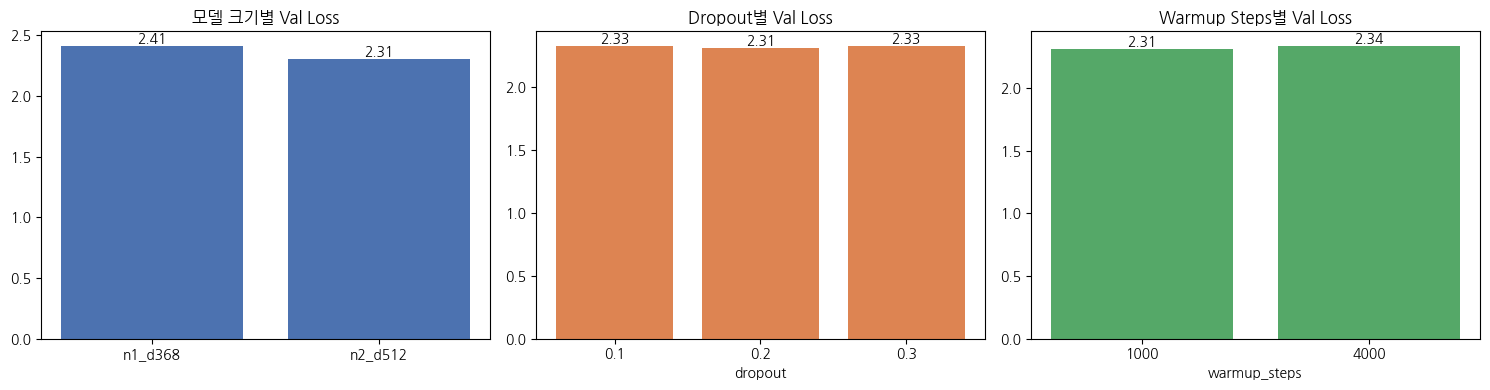

In [ ]:
# ---- 모델 크기 ----
size_results = []
for cand in CONFIG["size_candidates"]:
    print(f"=== 모델 크기 실험: {cand['name']} (n_layers={cand['n_layers']}, d_model={cand['d_model']}) ===")

    model, train_loss, val_loss, epochs_trained, _, _ = build_and_train(
        n_layers=cand["n_layers"], d_model=cand["d_model"], n_heads=CONFIG["n_heads"], d_ff=cand["d_ff"],
        dropout=CONFIG["base_dropout"], warmup_steps=CONFIG["base_warmup"], epochs=CONFIG["experiment_max_epochs"]
    )
    bleu = evaluate_bleu(model, val_questions[:CONFIG["experiment_eval_size"]], val_answers[:CONFIG["experiment_eval_size"]])

    size_results.append({**cand, "train_loss": train_loss, "val_loss": val_loss, "epochs": epochs_trained, "bleu": bleu})
    print(f"  train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, BLEU={bleu:.4f}\n")

    del model
    torch.cuda.empty_cache()

size_df = pd.DataFrame(size_results)

best_size = min(size_results, key=lambda r: r["val_loss"])
BEST_N_LAYERS, BEST_D_MODEL, BEST_D_FF = best_size["n_layers"], best_size["d_model"], best_size["d_ff"]

print(f"선택된 모델 크기: {best_size['name']} (val_loss={best_size['val_loss']:.4f}, BLEU={best_size['bleu']:.4f})")
size_df

# ---- Dropout ----
dropout_results = []
for dropout in CONFIG["dropout_candidates"]:
    print(f"=== Dropout 실험: {dropout} ===")

    model, train_loss, val_loss, epochs_trained, _, _ = build_and_train(
        n_layers=BEST_N_LAYERS, d_model=BEST_D_MODEL, n_heads=CONFIG["n_heads"], d_ff=BEST_D_FF,
        dropout=dropout, warmup_steps=CONFIG["base_warmup"], epochs=CONFIG["experiment_max_epochs"]
    )
    bleu = evaluate_bleu(model, val_questions[:CONFIG["experiment_eval_size"]], val_answers[:CONFIG["experiment_eval_size"]])

    dropout_results.append({"dropout": dropout, "train_loss": train_loss, "val_loss": val_loss, "epochs": epochs_trained, "bleu": bleu})
    print(f"  train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, BLEU={bleu:.4f}\n")

    del model
    torch.cuda.empty_cache()

dropout_df = pd.DataFrame(dropout_results)

best_dropout_row = min(dropout_results, key=lambda r: r["val_loss"])
BEST_DROPOUT = best_dropout_row["dropout"]

print(f"선택된 Dropout: {BEST_DROPOUT} (val_loss={best_dropout_row['val_loss']:.4f}, BLEU={best_dropout_row['bleu']:.4f})")
dropout_df

# ---- Warmup Steps ----
warmup_results = []
for warmup in CONFIG["warmup_candidates"]:
    print(f"=== Warmup Steps 실험: {warmup} ===")

    model, train_loss, val_loss, epochs_trained, _, _ = build_and_train(
        n_layers=BEST_N_LAYERS, d_model=BEST_D_MODEL, n_heads=CONFIG["n_heads"], d_ff=BEST_D_FF,
        dropout=BEST_DROPOUT, warmup_steps=warmup, epochs=CONFIG["experiment_max_epochs"]
    )
    bleu = evaluate_bleu(model, val_questions[:CONFIG["experiment_eval_size"]], val_answers[:CONFIG["experiment_eval_size"]])

    warmup_results.append({"warmup_steps": warmup, "train_loss": train_loss, "val_loss": val_loss, "epochs": epochs_trained, "bleu": bleu})
    print(f"  train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, BLEU={bleu:.4f}\n")

    del model
    torch.cuda.empty_cache()

warmup_df = pd.DataFrame(warmup_results)

best_warmup_row = min(warmup_results, key=lambda r: r["val_loss"])
BEST_WARMUP = best_warmup_row["warmup_steps"]

print(f"선택된 Warmup Steps: {BEST_WARMUP} (val_loss={best_warmup_row['val_loss']:.4f}, BLEU={best_warmup_row['bleu']:.4f})")
warmup_df

# ---- 결과 비교 차트 ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

labels = [r["name"] for r in size_results]
axes[0].bar(labels, [r["val_loss"] for r in size_results], color="#4C72B0")
axes[0].set_title("모델 크기별 Val Loss")
for i, r in enumerate(size_results):
    axes[0].text(i, r["val_loss"], f"{r['val_loss']:.2f}", ha="center", va="bottom")

labels = [str(r["dropout"]) for r in dropout_results]
axes[1].bar(labels, [r["val_loss"] for r in dropout_results], color="#DD8452")
axes[1].set_xlabel("dropout")
axes[1].set_title("Dropout별 Val Loss")
for i, r in enumerate(dropout_results):
    axes[1].text(i, r["val_loss"], f"{r['val_loss']:.2f}", ha="center", va="bottom")

labels = [str(r["warmup_steps"]) for r in warmup_results]
axes[2].bar(labels, [r["val_loss"] for r in warmup_results], color="#55A868")
axes[2].set_xlabel("warmup_steps")
axes[2].set_title("Warmup Steps별 Val Loss")
for i, r in enumerate(warmup_results):
    axes[2].text(i, r["val_loss"], f"{r['val_loss']:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 비교 2 : Attention x 구조 비교
Attention 3종 x 구조 2종, 6개 조합을 모두 학습해 비교했다. n_layers/d_model/dropout/warmup은 베이스라인 기준값을 그대로 썼고, 최종 선정 후 Dropout/Warmup만 다시 확인했다.

In [ ]:
class AdditiveAttention(nn.Module):

    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_a = nn.Linear(self.depth, self.depth, bias=False)
        self.v_a = nn.Linear(self.depth, 1, bias=False)
        self.linear = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        return x.view(bsz, seq_len, self.d_model)

    def forward(self, Q, K, V, mask=None):
        WQ, WK, WV = self.W_q(Q), self.W_k(K), self.W_v(V)
        Qh, Kh, Vh = self.split_heads(WQ), self.split_heads(WK), self.split_heads(WV)

        Qh_exp = Qh.unsqueeze(3)
        Kh_exp = Kh.unsqueeze(2)
        scores = self.v_a(torch.tanh(self.W_a(Qh_exp + Kh_exp))).squeeze(-1)

        if mask is not None:
            scores = scores + (mask * -1e9)

        attentions = F.softmax(scores, dim=-1)
        out = torch.matmul(attentions, Vh)
        out = self.combine_heads(out)
        out = self.linear(out)
        return out, attentions


class RelativeMultiHeadAttention(nn.Module):

    def __init__(self, d_model, num_heads, max_relative_position=16):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads
        self.max_relative_position = max_relative_position

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

        num_positions = 2 * max_relative_position + 1
        self.rel_emb_k = nn.Embedding(num_positions, self.depth)

    def _relative_positions(self, length_q, length_k, device):
        range_q = torch.arange(length_q, device=device).unsqueeze(1)
        range_k = torch.arange(length_k, device=device).unsqueeze(0)
        distance = range_k - range_q
        distance = torch.clamp(distance, -self.max_relative_position, self.max_relative_position)
        return distance + self.max_relative_position

    def split_heads(self, x):
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        return x.view(bsz, seq_len, self.d_model)

    def forward(self, Q, K, V, mask=None):
        length_q, length_k = Q.size(1), K.size(1)

        WQ, WK, WV = self.W_q(Q), self.W_k(K), self.W_v(V)
        Qh, Kh, Vh = self.split_heads(WQ), self.split_heads(WK), self.split_heads(WV)

        d_k = Qh.size(-1)
        content_score = torch.matmul(Qh, Kh.transpose(-1, -2))

        rel_idx = self._relative_positions(length_q, length_k, Q.device)
        rel_vectors = self.rel_emb_k(rel_idx)
        position_score = torch.einsum('bhqd,qkd->bhqk', Qh, rel_vectors)

        scaled_qk = (content_score + position_score) / torch.sqrt(torch.tensor(d_k, dtype=torch.float32, device=Q.device))

        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, Vh)
        out = self.combine_heads(out)
        out = self.linear(out)
        return out, attentions



def build_and_train_attn(attn_cls, attn_kwargs=None, epochs=None, patience=None,
                         dropout=None, warmup_steps=None, verbose=False):
    return build_and_train(
        n_layers=BEST_N_LAYERS, d_model=BEST_D_MODEL, n_heads=CONFIG['n_heads'], d_ff=BEST_D_FF,
        dropout=BEST_DROPOUT if dropout is None else dropout,
        warmup_steps=BEST_WARMUP if warmup_steps is None else warmup_steps,
        epochs=CONFIG['experiment_max_epochs'] if epochs is None else epochs,
        patience=patience, verbose=verbose, attn_cls=attn_cls, attn_kwargs=attn_kwargs)

Decoder-only는 인코더 없이 [질문] + <sep> + [답변]을 하나로 이어붙여 causal self-attention으로만 처리하는 구조다. loss는 <sep> 이후 답변 구간에 대해서만 계산했다.

In [ ]:
class DecoderOnlyLayer(nn.Module):
    """cross-attention이 없는, self-attention + FFN만 있는 GPT류 레이어. attn_cls로 attention 종류를 바꿀 수 있습니다."""
    def __init__(self, d_model, n_heads, d_ff, dropout, attn_cls=MultiHeadAttention, attn_kwargs=None):
        super().__init__()
        attn_kwargs = attn_kwargs or {}
        self.self_attn = attn_cls(d_model, n_heads, **attn_kwargs)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)

    def forward(self, x, causal_mask):
        residual = x
        out = self.norm_1(x)
        out, attn = self.self_attn(out, out, out, mask=causal_mask)
        out = self.do(out)
        out = out + residual

        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual
        return out, attn


class DecoderOnlyModel(nn.Module):
    """GPT류 Decoder-only 모델: 인코더 없이, [질문 + <sep> + 답변]을 하나의 시퀀스로 이어붙여
    causal self-attention 스택 하나로 처리합니다. attn_cls로 attention 종류를 바꿀 수 있습니다."""
    def __init__(self, n_layers, d_model, n_heads, d_ff, vocab_size, pos_len,
                 dropout=0.2, attn_cls=MultiHeadAttention, attn_kwargs=None):
        super().__init__()
        self.d_model = float(d_model)
        self.emb = nn.Embedding(vocab_size, d_model, padding_idx=0)

        pos_encoding_np = positional_encoding(pos_len, d_model)
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)
        self.layers = nn.ModuleList(
            [DecoderOnlyLayer(d_model, n_heads, d_ff, dropout, attn_cls, attn_kwargs) for _ in range(n_layers)]
        )
        self.final_norm = nn.LayerNorm(d_model)
        self.fc = nn.Linear(d_model, vocab_size)

        for parameter in self.parameters():
            if parameter.ndim > 1:
                nn.init.xavier_uniform_(parameter)
        nn.init.normal_(self.emb.weight, std=d_model ** -0.5)
        with torch.no_grad():
            self.emb.weight[0].zero_()
        nn.init.zeros_(self.fc.bias)

    def forward(self, x, causal_mask):
        seq_len = x.size(1)
        out = self.emb(x) * math.sqrt(self.d_model)
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)

        for layer in self.layers:
            out, _ = layer(out, causal_mask)

        out = self.final_norm(out)
        logits = self.fc(out)
        return logits


def generate_decoder_only_mask(seq: torch.Tensor) -> torch.Tensor:
    """padding mask + lookahead mask 결합 (Decoder-only는 시퀀스 전체에 causal 마스크 하나만 적용)"""
    size = seq.size(1)
    padding_mask = (seq == 0).unsqueeze(1).unsqueeze(2).float()
    lookahead_mask = torch.triu(torch.ones(size, size, device=seq.device), diagonal=1).unsqueeze(0).unsqueeze(1)
    return torch.max(padding_mask, lookahead_mask)

Decoder-only용 데이터를 준비했다. <sep> 토큰을 vocab에 추가했고 [질문] + <sep> + <start>...<end> 형태로 이어붙였다.

Decoder-only Train: 30000개 / Val: 1162개, DO_MAX_LEN=53
=== Encoder-Decoder + Scaled Dot-Product ===
[동일 설정의 최적 체크포인트 재사용] build_and_train
  val_loss=2.3076, BLEU=0.0917

=== Encoder-Decoder + Additive (Bahdanau) ===
  val_loss=2.3075, BLEU=0.1073

=== Encoder-Decoder + Relative Position ===
  val_loss=2.3124, BLEU=0.0756

=== Decoder-only + Scaled Dot-Product ===
  val_loss=2.3368, BLEU=0.1154

=== Decoder-only + Additive (Bahdanau) ===
  val_loss=2.3432, BLEU=0.1122

=== Decoder-only + Relative Position ===
  val_loss=2.2914, BLEU=0.1056



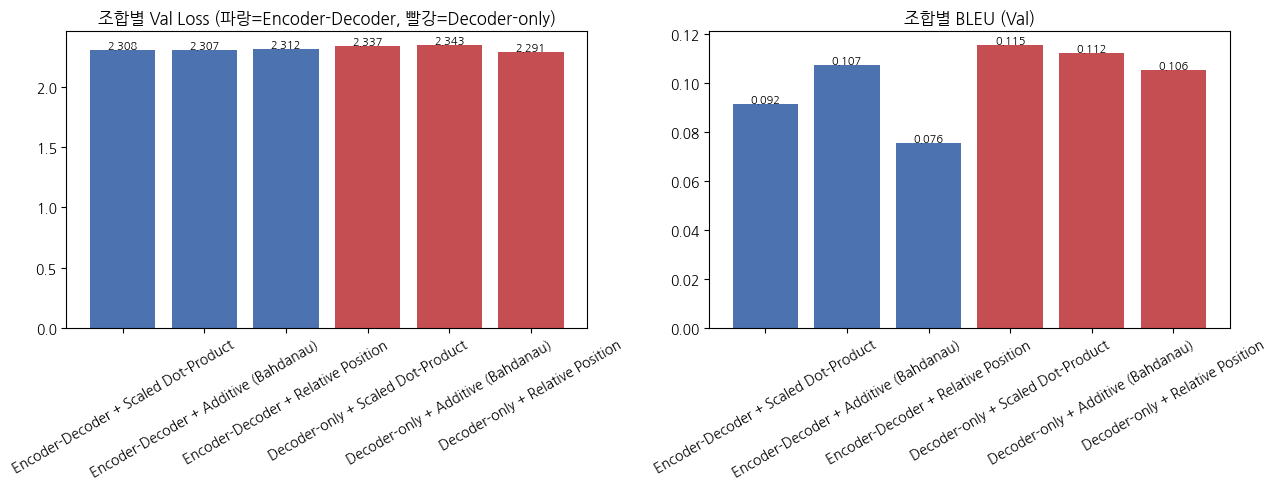

In [ ]:
# Decoder-only용 vocab: 기존 word2idx에 <sep> 토큰만 추가 (기존 인덱스는 그대로 유지됨)
if "<sep>" not in word2idx:
    word2idx["<sep>"] = len(word2idx)
    idx2word[word2idx["<sep>"]] = "<sep>"
DO_VOCAB_SIZE = len(word2idx)


def build_decoder_only_sequence(que_tokens, ans_tokens, word2idx, max_len):
    """[질문] + <sep> + [<start> ... <end>] 형태로 이어붙이고, loss_mask(답변 구간만 1)도 함께 만듭니다."""
    que_ids = tokens_to_ids(que_tokens, word2idx)
    ans_ids = tokens_to_ids(ans_tokens, word2idx)  # ans_tokens는 이미 <start>, <end> 포함
    sep_id = word2idx["<sep>"]

    input_ids = que_ids + [sep_id] + ans_ids
    # <start> 토큰 자체는 <sep> 뒤에 항상 결정적으로 오므로(예측이 거저 맞음) loss 대상에서 제외한다.
    # Encoder-Decoder가 <start>를 디코더 입력으로 그냥 주고 예측 대상에서 빼는 것과 동일하게 맞춰,
    # 두 구조의 loss가 같은 기준(= 실제 답변 내용 토큰에 대해서만 평균)으로 비교되도록 한다.
    loss_mask = [0] * (len(que_ids) + 2) + [1] * (len(ans_ids) - 1)

    input_ids = input_ids[:max_len] + [0] * max(0, max_len - len(input_ids))
    loss_mask = loss_mask[:max_len] + [0] * max(0, max_len - len(loss_mask))

    return input_ids, loss_mask


DO_MAX_LEN = CONFIG["max_tokens"] * 2 + 3

do_train_inputs, do_train_masks = [], []
for q, a in zip(que_corpus, ans_corpus):
    ids, mask_ = build_decoder_only_sequence(q, a, word2idx, DO_MAX_LEN)
    do_train_inputs.append(ids)
    do_train_masks.append(mask_)

do_val_inputs, do_val_masks = [], []
for q, a in zip(val_que_corpus, val_ans_corpus):
    ids, mask_ = build_decoder_only_sequence(q, a, word2idx, DO_MAX_LEN)
    do_val_inputs.append(ids)
    do_val_masks.append(mask_)

do_train_inputs_t = torch.tensor(do_train_inputs, dtype=torch.long)
do_train_masks_t = torch.tensor(do_train_masks, dtype=torch.float32)
do_val_inputs_t = torch.tensor(do_val_inputs, dtype=torch.long)
do_val_masks_t = torch.tensor(do_val_masks, dtype=torch.float32)

do_train_dataset = TensorDataset(do_train_inputs_t, do_train_masks_t)
do_train_dataloader = DataLoader(do_train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, pin_memory=True)

do_val_dataset = TensorDataset(do_val_inputs_t, do_val_masks_t)
do_val_dataloader = DataLoader(do_val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, pin_memory=True)

print(f"Decoder-only Train: {len(do_train_dataset)}개 / Val: {len(do_val_dataset)}개, DO_MAX_LEN={DO_MAX_LEN}")

# ---- Decoder-only 학습/평가 함수 ----
def decoder_only_loss(logits, input_ids, loss_mask):
    """다음 토큰 예측 loss. loss_mask==1인 위치(=답변 구간)에 대해서만 평균을 냅니다."""
    pred = logits[:, :-1, :]
    gold = input_ids[:, 1:]
    mask = loss_mask[:, 1:]

    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), gold.contiguous().view(-1), reduction='none')
    loss_ = loss_.view(gold.size())
    loss_ = loss_ * mask
    return loss_.sum() / mask.sum().clamp(min=1)


def evaluate_do_loss(model, dataloader):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    with torch.no_grad():
        for input_ids, loss_mask in dataloader:
            input_ids, loss_mask = input_ids.to(device), loss_mask.to(device)
            causal_mask = generate_decoder_only_mask(input_ids)
            logits = model(input_ids, causal_mask)
            loss = decoder_only_loss(logits, input_ids, loss_mask)
            weight = loss_mask[:, 1:].sum().item()
            total_loss += loss.item() * weight
            total_tokens += weight
    return total_loss / max(total_tokens, 1)


@cache_training
def build_and_train_decoder_only(attn_cls=MultiHeadAttention, attn_kwargs=None, epochs=None, patience=None, dropout=None, warmup_steps=None, verbose=False):
    """지정된 attention 종류로 Decoder-only 모델을 학습합니다.
    n_layers/d_model/d_ff는 BEST_* 값을 그대로 쓰고, dropout/warmup_steps는 인자로 넘기면 그 값을,
    안 넘기면 BEST_DROPOUT/BEST_WARMUP을 씁니다 (최종 승자 재확인 단계에서 override용으로 사용)."""
    set_seed(CONFIG["seed"])
    epochs = epochs if epochs is not None else CONFIG["experiment_max_epochs"]
    patience = patience if patience is not None else CONFIG["early_stopping_patience"]
    dropout = dropout if dropout is not None else BEST_DROPOUT
    warmup_steps = warmup_steps if warmup_steps is not None else BEST_WARMUP

    model = DecoderOnlyModel(
        n_layers=BEST_N_LAYERS, d_model=BEST_D_MODEL, n_heads=CONFIG["n_heads"], d_ff=BEST_D_FF,
        vocab_size=DO_VOCAB_SIZE, pos_len=DO_MAX_LEN, dropout=dropout,
        attn_cls=attn_cls, attn_kwargs=attn_kwargs
    ).to(device)

    scheduler = LearningRateScheduler(warmup_steps=warmup_steps, peak_lr=CONFIG["peak_lr"])
    optimizer = torch.optim.Adam(model.parameters(), lr=scheduler(1), betas=(0.9, 0.98), eps=1e-9)

    best_val_loss = float("inf")
    best_state = None
    best_train_loss, best_epoch = None, 0
    patience_counter = 0
    global_step = 0
    final_train_loss = None
    epochs_trained = 0
    train_loss_history, val_loss_history = [], []

    for epoch in range(epochs):
        model.train()
        total_loss, total_tokens = 0.0, 0
        for input_ids, loss_mask in do_train_dataloader:
            global_step += 1
            lr = scheduler(global_step)
            for pg in optimizer.param_groups:
                pg['lr'] = lr

            input_ids_d, loss_mask_d = input_ids.to(device), loss_mask.to(device)
            causal_mask = generate_decoder_only_mask(input_ids_d)

            optimizer.zero_grad()
            logits = model(input_ids_d, causal_mask)
            loss = decoder_only_loss(logits, input_ids_d, loss_mask_d)
            if not torch.isfinite(loss):
                raise FloatingPointError("학습 loss가 NaN/Inf입니다.")
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            weight = loss_mask[:, 1:].sum().item()
            total_loss += loss.item() * weight
            total_tokens += weight

        train_loss = total_loss / max(total_tokens, 1)
        val_loss = evaluate_do_loss(model, do_val_dataloader)
        final_train_loss = train_loss
        epochs_trained = epoch + 1
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

        if verbose:
            print(f"  epoch {epoch+1}/{epochs} - train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_train_loss, best_epoch = train_loss, epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f"  -> 검증 loss가 {patience}에폭 연속 개선되지 않아 {epoch+1}에폭에서 조기 종료합니다.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.best_epoch = best_epoch
    final_train_loss = best_train_loss
    return model, final_train_loss, best_val_loss, epochs_trained, train_loss_history, val_loss_history


@torch.inference_mode()
def translate_chat_decoder_only(sentence, model, word2idx, idx2word, max_len=None):
    model.eval()
    max_len = max_len if max_len is not None else DO_MAX_LEN
    tokens = tokenizer.morphs(preprocess_sentence(sentence))
    que_ids = tokens_to_ids(tokens[:CONFIG["max_tokens"]], word2idx)
    sep_id = word2idx["<sep>"]
    start_id = word2idx["<start>"]

    input_ids = que_ids + [sep_id, start_id]
    result_ids = []

    for _ in range(min(CONFIG["max_tokens"] + 1, max_len - len(input_ids))):
        cur = torch.tensor([input_ids], dtype=torch.long, device=device)
        causal_mask = generate_decoder_only_mask(cur)
        logits = model(cur, causal_mask)

        next_logits = logits[0, -1].clone()
        next_logits[word2idx["<pad>"]] = -float("inf")
        next_logits[word2idx["<start>"]] = -float("inf")
        next_logits[word2idx["<sep>"]] = -float("inf")
        if result_ids:
            next_logits[result_ids[-1]] = -float("inf")
        for banned_id in get_banned_tokens(result_ids, CONFIG["no_repeat_ngram_size"]):
            next_logits[banned_id] = -float("inf")

        predicted_id = next_logits.argmax(dim=-1).item()
        if predicted_id == word2idx["<end>"]:
            break

        result_ids.append(predicted_id)
        input_ids.append(predicted_id)

    return " ".join(idx2word.get(i, "<unk>") for i in result_ids)


def evaluate_bleu_decoder_only(model, que_list, ans_list):
    return evaluate_bleu(model, que_list, ans_list,
        decode_fn=lambda s, m: translate_chat_decoder_only(s, m, word2idx, idx2word))

# ---- 6개 조합 실행 ----
attn_candidates = [
    {"name": "Scaled Dot-Product", "cls": MultiHeadAttention, "kwargs": {}},
    {"name": "Additive (Bahdanau)", "cls": AdditiveAttention, "kwargs": {}},
    {"name": "Relative Position", "cls": RelativeMultiHeadAttention, "kwargs": {"max_relative_position": 8}},
]

combo_results = []

for cand in attn_candidates:
    print(f"=== Encoder-Decoder + {cand['name']} ===")
    model, train_loss, val_loss, epochs_trained_, _, _ = build_and_train_attn(
        cand["cls"], cand["kwargs"], epochs=CONFIG["experiment_max_epochs"]
    )
    bleu = evaluate_bleu(model, val_questions[:CONFIG["experiment_eval_size"]], val_answers[:CONFIG["experiment_eval_size"]])
    combo_results.append({"arch": "encoder_decoder", "attn_name": cand["name"], "attn_cls": cand["cls"], "attn_kwargs": cand["kwargs"],
                           "train_loss": train_loss, "val_loss": val_loss, "epochs": epochs_trained_, "bleu": bleu})
    print(f"  val_loss={val_loss:.4f}, BLEU={bleu:.4f}\n")
    del model
    torch.cuda.empty_cache()

for cand in attn_candidates:
    print(f"=== Decoder-only + {cand['name']} ===")
    model, train_loss, val_loss, epochs_trained_, _, _ = build_and_train_decoder_only(
        cand["cls"], cand["kwargs"], epochs=CONFIG["experiment_max_epochs"]
    )
    bleu = evaluate_bleu_decoder_only(model, val_questions[:CONFIG["experiment_eval_size"]], val_answers[:CONFIG["experiment_eval_size"]])
    combo_results.append({"arch": "decoder_only", "attn_name": cand["name"], "attn_cls": cand["cls"], "attn_kwargs": cand["kwargs"],
                           "train_loss": train_loss, "val_loss": val_loss, "epochs": epochs_trained_, "bleu": bleu})
    print(f"  val_loss={val_loss:.4f}, BLEU={bleu:.4f}\n")
    del model
    torch.cuda.empty_cache()

combo_df = pd.DataFrame(combo_results)
combo_df["구성"] = combo_df.apply(
    lambda r: ("Encoder-Decoder" if r["arch"] == "encoder_decoder" else "Decoder-only") + " + " + r["attn_name"], axis=1
)
combo_df[["구성", "train_loss", "val_loss", "epochs", "bleu"]]

# ---- 조합 비교 차트 ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#4C72B0" if a == "encoder_decoder" else "#C44E52" for a in combo_df["arch"]]

axes[0].bar(combo_df["구성"], combo_df["val_loss"], color=colors)
axes[0].set_title("조합별 Val Loss (파랑=Encoder-Decoder, 빨강=Decoder-only)")
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(combo_df["val_loss"]):
    axes[0].text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

axes[1].bar(combo_df["구성"], combo_df["bleu"], color=colors)
axes[1].set_title("조합별 BLEU (Val)")
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(combo_df["bleu"]):
    axes[1].text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

### 최종 구성 선택
6개 조합 중 Val Loss가 가장 낮은 조합을 최종으로 선택했다.

In [ ]:
best_row = combo_df.loc[combo_df["val_loss"].idxmin()]

FINAL_ARCH = best_row["arch"]
FINAL_ATTN_CLS = best_row["attn_cls"]
FINAL_ATTN_KWARGS = best_row["attn_kwargs"]
FINAL_ATTN_NAME = best_row["attn_name"]

print(f"선택된 최종 구성 -> {best_row['구성']} (val_loss={best_row['val_loss']:.4f}, BLEU={best_row['bleu']:.4f})")

선택된 최종 구성 -> Decoder-only + Relative Position (val_loss=2.2914, BLEU=0.1056)


### 최종 구성 재검증
최종 선정된 구성 위에서 Dropout/Warmup만 다시 확인했다 (n_layers/d_model은 계산 비용상 그대로 유지했다).

=== [최종 구성] Dropout 재확인: 0.1 ===
  val_loss=2.3129, BLEU=0.0834

=== [최종 구성] Dropout 재확인: 0.2 ===
[동일 설정의 최적 체크포인트 재사용] build_and_train_decoder_only
  val_loss=2.2914, BLEU=0.1056

=== [최종 구성] Dropout 재확인: 0.3 ===
  val_loss=2.3260, BLEU=0.1090

베이스라인 기준 선택: 0.2 -> 최종 구성 재확인 결과: 0.2
=== [최종 구성] Warmup 재확인: 1000 ===
[동일 설정의 최적 체크포인트 재사용] build_and_train_decoder_only
  val_loss=2.2914, BLEU=0.1056

=== [최종 구성] Warmup 재확인: 4000 ===
  val_loss=2.3267, BLEU=0.0975

베이스라인 기준 선택: 1000 -> 최종 구성 재확인 결과: 1000


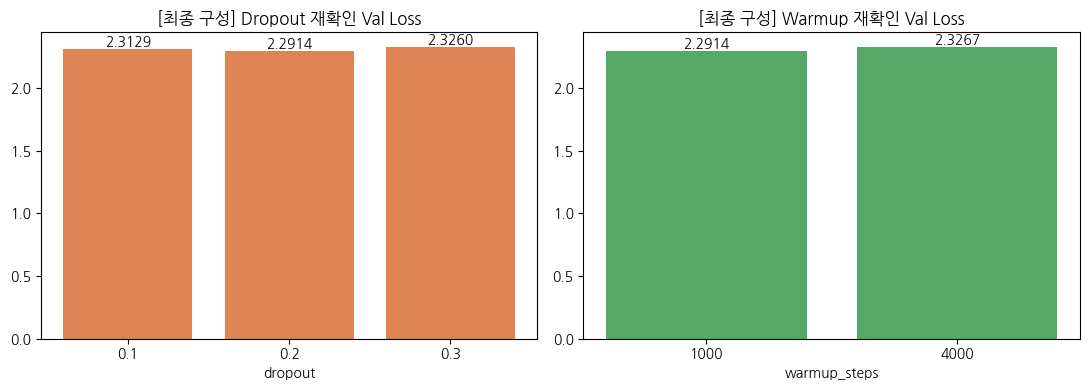

최종 구성에서 다시 확인된 하이퍼파라미터 -> dropout=0.2, warmup_steps=1000


In [ ]:
# 실험4-2에서 BEST_DROPOUT/BEST_WARMUP을 최종 구성 기준으로 덮어쓰기 전에,
# 베이스라인(실험2·3 기준) 값을 따로 보관해둔다 (뒤에서 베이스라인과의 최종 비교에 사용).
BASELINE_DROPOUT = BEST_DROPOUT
BASELINE_WARMUP = BEST_WARMUP


def train_final_combo(dropout=None, warmup_steps=None, epochs=None, verbose=False):
    """FINAL_ARCH / FINAL_ATTN_CLS로 고정된 최종 구성에서, dropout/warmup_steps만 바꿔 학습합니다."""
    if FINAL_ARCH == "encoder_decoder":
        return build_and_train_attn(
            FINAL_ATTN_CLS, FINAL_ATTN_KWARGS, epochs=epochs, dropout=dropout, warmup_steps=warmup_steps, verbose=verbose
        )
    else:
        return build_and_train_decoder_only(
            FINAL_ATTN_CLS, FINAL_ATTN_KWARGS, epochs=epochs, dropout=dropout, warmup_steps=warmup_steps, verbose=verbose
        )


def evaluate_final_bleu(model):
    if FINAL_ARCH == "encoder_decoder":
        return evaluate_bleu(model, val_questions[:CONFIG["experiment_eval_size"]], val_answers[:CONFIG["experiment_eval_size"]])
    else:
        return evaluate_bleu_decoder_only(model, val_questions[:CONFIG["experiment_eval_size"]], val_answers[:CONFIG["experiment_eval_size"]])

# ---- Dropout 재확인 ----
dropout_recheck_results = []
for dropout in CONFIG["dropout_candidates"]:
    print(f"=== [최종 구성] Dropout 재확인: {dropout} ===")
    model, train_loss, val_loss, epochs_trained_, _, _ = train_final_combo(
        dropout=dropout, warmup_steps=BEST_WARMUP, epochs=CONFIG["experiment_max_epochs"]
    )
    bleu = evaluate_final_bleu(model)
    dropout_recheck_results.append({"dropout": dropout, "val_loss": val_loss, "bleu": bleu})
    print(f"  val_loss={val_loss:.4f}, BLEU={bleu:.4f}\n")
    del model
    torch.cuda.empty_cache()

dropout_recheck_df = pd.DataFrame(dropout_recheck_results)
best_dropout_recheck = dropout_recheck_df.loc[dropout_recheck_df["val_loss"].idxmin(), "dropout"]
print(f"베이스라인 기준 선택: {BEST_DROPOUT} -> 최종 구성 재확인 결과: {best_dropout_recheck}")
BEST_DROPOUT = best_dropout_recheck

dropout_recheck_df

# ---- Warmup 재확인 ----
warmup_recheck_results = []
for warmup in CONFIG["warmup_candidates"]:
    print(f"=== [최종 구성] Warmup 재확인: {warmup} ===")
    model, train_loss, val_loss, epochs_trained_, _, _ = train_final_combo(
        dropout=BEST_DROPOUT, warmup_steps=warmup, epochs=CONFIG["experiment_max_epochs"]
    )
    bleu = evaluate_final_bleu(model)
    warmup_recheck_results.append({"warmup_steps": warmup, "val_loss": val_loss, "bleu": bleu})
    print(f"  val_loss={val_loss:.4f}, BLEU={bleu:.4f}\n")
    del model
    torch.cuda.empty_cache()

warmup_recheck_df = pd.DataFrame(warmup_recheck_results)
best_warmup_recheck = warmup_recheck_df.loc[warmup_recheck_df["val_loss"].idxmin(), "warmup_steps"]
print(f"베이스라인 기준 선택: {BEST_WARMUP} -> 최종 구성 재확인 결과: {best_warmup_recheck}")
BEST_WARMUP = best_warmup_recheck

warmup_recheck_df

# ---- 재확인 결과 차트 ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

labels = [str(r) for r in dropout_recheck_df["dropout"]]
axes[0].bar(labels, dropout_recheck_df["val_loss"], color="#DD8452")
axes[0].set_xlabel("dropout")
axes[0].set_title("[최종 구성] Dropout 재확인 Val Loss")
for i, v in enumerate(dropout_recheck_df["val_loss"]):
    axes[0].text(i, v, f"{v:.4f}", ha="center", va="bottom")

labels = [str(r) for r in warmup_recheck_df["warmup_steps"]]
axes[1].bar(labels, warmup_recheck_df["val_loss"], color="#55A868")
axes[1].set_xlabel("warmup_steps")
axes[1].set_title("[최종 구성] Warmup 재확인 Val Loss")
for i, v in enumerate(warmup_recheck_df["val_loss"]):
    axes[1].text(i, v, f"{v:.4f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(f"최종 구성에서 다시 확인된 하이퍼파라미터 -> dropout={BEST_DROPOUT}, warmup_steps={BEST_WARMUP}")

### 최종 훈련
재검증된 하이퍼파라미터와 최종 구성으로 max_epochs까지 학습했다.

최종 하이퍼파라미터 -> n_layers=2, d_model=512, d_ff=2048, dropout=0.2, warmup_steps=1000 (dropout/warmup은 최종 구성 재확인 값)
최종 구성 -> 구조: Decoder-only, Attention: Relative Position
(최대 200 에폭까지, 검증 loss가 5에폭 연속 개선 안 되면 조기 종료)
[동일 설정의 최적 체크포인트 재사용] build_and_train_decoder_only

최종 모델 훈련 완료 - 10 에폭 사용 / Train Loss: 1.2196 / Val Loss: 2.2914
최적 체크포인트: 5에폭 / Train: 1.2196 / Val: 2.2914


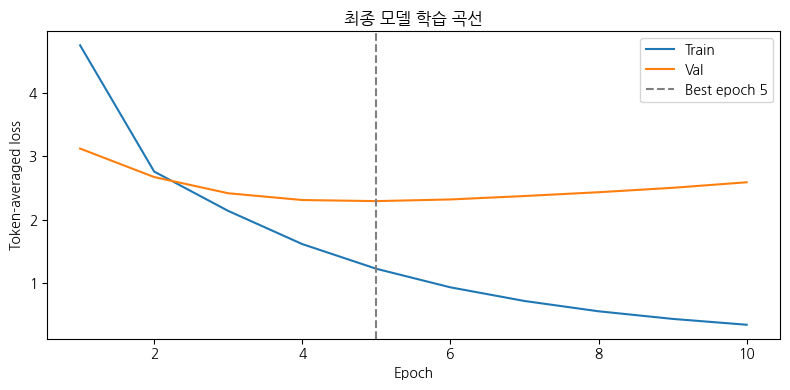

CPU times: user 82.6 ms, sys: 16 ms, total: 98.6 ms
Wall time: 98 ms


In [ ]:
%%time

print(f"최종 하이퍼파라미터 -> n_layers={BEST_N_LAYERS}, d_model={BEST_D_MODEL}, d_ff={BEST_D_FF}, "
      f"dropout={BEST_DROPOUT}, warmup_steps={BEST_WARMUP} (dropout/warmup은 최종 구성 재확인 값)")
print(f"최종 구성 -> 구조: {'Encoder-Decoder' if FINAL_ARCH == 'encoder_decoder' else 'Decoder-only'}, Attention: {FINAL_ATTN_NAME}")
print(f"(최대 {CONFIG['max_epochs']} 에폭까지, 검증 loss가 {CONFIG['early_stopping_patience']}에폭 연속 개선 안 되면 조기 종료)")

chat_transformer, final_train_loss, final_val_loss, epochs_trained, train_loss_history, val_loss_history = train_final_combo(
    dropout=BEST_DROPOUT, warmup_steps=BEST_WARMUP, epochs=CONFIG["max_epochs"], verbose=True
)

print(f"\n최종 모델 훈련 완료 - {epochs_trained} 에폭 사용 / Train Loss: {final_train_loss:.4f} / Val Loss: {final_val_loss:.4f}")

best_epoch = chat_transformer.best_epoch
print(f'최적 체크포인트: {best_epoch}에폭 / Train: {final_train_loss:.4f} / Val: {final_val_loss:.4f}')
fig, ax = plt.subplots(figsize=(8, 4))
xs = range(1, len(train_loss_history) + 1)
ax.plot(xs, train_loss_history, label='Train')
ax.plot(xs, val_loss_history, label='Val')
ax.axvline(best_epoch, linestyle='--', color='gray', label=f'Best epoch {best_epoch}')
ax.set(xlabel='Epoch', ylabel='Token-averaged loss', title='최종 모델 학습 곡선')
ax.legend()
plt.tight_layout()
plt.show()
torch.save(chat_transformer.state_dict(), artifact_dir / 'final_model_state.pt')
with (artifact_dir / 'model_config.json').open('w', encoding='utf-8') as f:
    json.dump({'config': CONFIG, 'architecture': FINAL_ARCH, 'attention': FINAL_ATTN_NAME,
               'attention_kwargs': FINAL_ATTN_KWARGS,
               'layers': int(BEST_N_LAYERS), 'd_model': int(BEST_D_MODEL), 'd_ff': int(BEST_D_FF),
               'dropout': float(BEST_DROPOUT), 'warmup': int(BEST_WARMUP),
               'word2idx': word2idx, 'token_pos': token_pos, 'best_epoch': int(best_epoch)},
              f, ensure_ascii=False, indent=2)

### 디코딩 전략
Greedy와 Beam Search를 비교했다.

Beam Search는 Encoder-Decoder 계열에서만 구현했고, 최종 구성이 Decoder-only면 Greedy로 진행했다.

In [ ]:
@torch.inference_mode()
def translate_chat_beam(sentence, model, word2idx, idx2word, max_len=CHAT_MAX_LEN, beam_size=CONFIG["beam_size"]):
    model.eval()
    tokens = tokenizer.morphs(preprocess_sentence(sentence))
    ids = tokens_to_ids(tokens[:CONFIG["max_tokens"]], word2idx)
    ids = ids[:max_len] + [0] * max(0, max_len - len(ids))
    src_in = torch.tensor([ids], dtype=torch.long, device=device)

    beams = [(0.0, [word2idx["<start>"]], False)]

    for _ in range(min(max_len, CONFIG["max_tokens"] + 1)):
        candidates = []
        for score, seq, done in beams:
            if done:
                candidates.append((score, seq, done))
                continue

            output = torch.tensor([seq], dtype=torch.long, device=device)
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src_in, output)
            predictions, _, _, _ = model(src_in, output, enc_mask, dec_enc_mask, dec_mask)
            log_probs = F.log_softmax(predictions[0, -1], dim=-1).clone()
            log_probs[word2idx["<pad>"]] = -float("inf")
            log_probs[word2idx["<start>"]] = -float("inf")

            gen_so_far = seq[1:]
            if gen_so_far:
                log_probs[gen_so_far[-1]] = -float("inf")
            for banned_id in get_banned_tokens(gen_so_far, CONFIG["no_repeat_ngram_size"]):
                log_probs[banned_id] = -float("inf")

            topk_log_probs, topk_ids = torch.topk(log_probs, beam_size)
            for lp, idx in zip(topk_log_probs.tolist(), topk_ids.tolist()):
                new_seq = seq + [idx]
                new_done = (idx == word2idx["<end>"])
                candidates.append((score + lp, new_seq, new_done))

        candidates.sort(key=lambda x: x[0], reverse=True)
        beams = candidates[:beam_size]

        if all(done for _, _, done in beams):
            break

    _, best_seq, _ = beams[0]
    seq = best_seq[1:]
    if word2idx["<end>"] in seq:
        seq = seq[:seq.index(word2idx["<end>"])]

    return " ".join(idx2word.get(i, "<unk>") for i in seq)

# ---- Greedy vs Beam 비교 ----
def compare_decoding(model, que_list, ans_list, beam_size=CONFIG['beam_size'], verbose=True):
    greedy = score_responses(lambda q: translate_chat(q, model, word2idx, idx2word), que_list, ans_list, verbose)
    beam = score_responses(lambda q: translate_chat_beam(q, model, word2idx, idx2word, beam_size=beam_size), que_list, ans_list, verbose)
    return greedy['bleu'], beam['bleu']

# ---- 비교 실행 ----
if FINAL_ARCH == "encoder_decoder":
    greedy_bleu, beam_bleu = compare_decoding(
        chat_transformer, val_questions[:CONFIG["experiment_eval_size"]], val_answers[:CONFIG["experiment_eval_size"]], verbose=False
    )
    print(f"Greedy 평균 BLEU: {greedy_bleu:.4f}")
    print(f"Beam(size={CONFIG['beam_size']}) 평균 BLEU: {beam_bleu:.4f}")
else:
    greedy_bleu, beam_bleu = None, None
    print("최종 구성이 Decoder-only라 Beam Search 비교는 건너뜁니다 (Greedy만 지원).")

# ---- 비교 차트 ----
if FINAL_ARCH == "encoder_decoder":
    fig, ax = plt.subplots(figsize=(4, 4))
    labels = ["Greedy", f"Beam (size={CONFIG['beam_size']})"]
    values = [greedy_bleu, beam_bleu]
    ax.bar(labels, values, color=["#4C72B0", "#C44E52"])
    ax.set_ylabel("BLEU Score")
    ax.set_title("디코딩 전략 비교 (Val)")
    for i, v in enumerate(values):
        ax.text(i, v, f"{v:.4f}", ha="center", va="bottom")
    plt.show()
else:
    print("(Decoder-only 구성이라 디코딩 전략 비교 차트는 생략합니다.)")

# ---- 최종 디코딩 전략 선택 ----
if FINAL_ARCH == "encoder_decoder":
    if beam_bleu > greedy_bleu:
        FINAL_DECODING = "beam"
        def generate_answer(sentence):
            return translate_chat_beam(sentence, chat_transformer, word2idx, idx2word, beam_size=CONFIG["beam_size"])
    else:
        FINAL_DECODING = "greedy"
        def generate_answer(sentence):
            return translate_chat(sentence, chat_transformer, word2idx, idx2word)
else:
    FINAL_DECODING = "greedy (decoder-only)"
    def generate_answer(sentence):
        return translate_chat_decoder_only(sentence, chat_transformer, word2idx, idx2word)

print("선택된 디코딩 전략:", FINAL_DECODING)

최종 구성이 Decoder-only라 Beam Search 비교는 건너뜁니다 (Greedy만 지원).
(Decoder-only 구성이라 디코딩 전략 비교 차트는 생략합니다.)
선택된 디코딩 전략: greedy (decoder-only)


### 최종 선택 요약

In [ ]:
print("=" * 50)
print("비교실험 결과 요약")
print("=" * 50)

print("\n[모델 크기]")
print(size_df.to_string(index=False))

print("\n[Attention x 구조 전체 조합 (베이스라인 dropout/warmup 기준)]")
print(combo_df[["구성", "val_loss", "bleu"]].to_string(index=False))

print("\n[최종 구성 Dropout 재확인]")
print(dropout_recheck_df.to_string(index=False))

print("\n[최종 구성 Warmup 재확인]")
print(warmup_recheck_df.to_string(index=False))

if FINAL_ARCH == "encoder_decoder":
    print("\n[디코딩 전략]")
    print(f"  Greedy BLEU: {greedy_bleu:.4f}")
    print(f"  Beam BLEU  : {beam_bleu:.4f}")

print("\n" + "=" * 50)
print("최종 선택된 설정")
print("=" * 50)
print(f"n_layers        : {BEST_N_LAYERS}")
print(f"d_model         : {BEST_D_MODEL}")
print(f"d_ff            : {BEST_D_FF}")
print(f"dropout         : {BEST_DROPOUT} (최종 구성 재확인 값)")
print(f"warmup_steps    : {BEST_WARMUP} (최종 구성 재확인 값)")
print(f"구조            : {'Encoder-Decoder' if FINAL_ARCH == 'encoder_decoder' else 'Decoder-only'}")
print(f"attention       : {FINAL_ATTN_NAME}")
print(f"decoding        : {FINAL_DECODING}")
print(f"실제 학습된 에폭 : {epochs_trained} (Early Stopping)")
print(f"최적 에폭 Train Loss : {final_train_loss:.4f}")
print(f"최적 에폭 Val Loss   : {final_val_loss:.4f}")
print("복원한 최적 에폭:", chat_transformer.best_epoch)

비교실험 결과 요약

[모델 크기]
   name  n_layers  d_model  d_ff  train_loss  val_loss  epochs     bleu
n1_d368         1      368  1024    1.423270  2.412799      11 0.073217
n2_d512         2      512  2048    1.496815  2.307581       9 0.091652

[Attention x 구조 전체 조합 (베이스라인 dropout/warmup 기준)]
                                   구성  val_loss     bleu
 Encoder-Decoder + Scaled Dot-Product  2.307581 0.091652
Encoder-Decoder + Additive (Bahdanau)  2.307496 0.107332
  Encoder-Decoder + Relative Position  2.312385 0.075552
    Decoder-only + Scaled Dot-Product  2.336821 0.115446
   Decoder-only + Additive (Bahdanau)  2.343202 0.112231
     Decoder-only + Relative Position  2.291356 0.105552

[최종 구성 Dropout 재확인]
 dropout  val_loss     bleu
     0.1  2.312892 0.083351
     0.2  2.291356 0.105552
     0.3  2.325997 0.108952

[최종 구성 Warmup 재확인]
 warmup_steps  val_loss     bleu
         1000  2.291356 0.105552
         4000  2.326693 0.097474

최종 선택된 설정
n_layers        : 2
d_model         : 512
d_ff      

## Chat bot 답변 생성

In [ ]:
test_sentences = {
    "기본 예문": [
        "지루하다, 놀러가고 싶어.",
        "오늘 일찍 일어났더니 피곤하다.",
        "간만에 여자친구랑 데이트 하기로 했어.",
    ],

    "추가 질문": [
        "요즘 너무 스트레스 받아.",
        "친구랑 싸웠는데 화해하고 싶어.",
        "오늘 기분이 별로야.",
    ],

    "조금 더 어려운 질문": [
        "친구에게 사과하고 싶은데 어떻게 말해야 할까?",
        "열심히 했는데 결과가 좋지 않아서 속상해.",
        "좋아하는 사람한테 먼저 연락해도 괜찮을까?",
        "해야 할 일이 많은데 아무것도 하기 싫어.",
    ]
}

for category, sentences in test_sentences.items():
    print("=" * 60)
    print(category)
    print("=" * 60)

    for sentence in sentences:
        print("Q:", sentence)
        raw_answer = generate_answer(sentence)
        print("A:", detokenize_answer(raw_answer) or "[빈 답변]")
        print("  평가용 형태소:", raw_answer)
        print()

기본 예문
Q: 지루하다, 놀러가고 싶어.
A: 저도요!!
  평가용 형태소: 저 도 요 !!

Q: 오늘 일찍 일어났더니 피곤하다.
A: 오늘 일찍 주무세요.
  평가용 형태소: 오늘 일찍 주무 이 세요 .

Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 좋은 곳으로가어 보세요.
  평가용 형태소: 좋 은 곳 으로 가 어 보 세요 .

추가 질문
Q: 요즘 너무 스트레스 받아.
A: 자신을 더 사랑해 주세요.
  평가용 형태소: 자신 을 더 사랑 하 어 주 세요 .

Q: 친구랑 싸웠는데 화해하고 싶어.
A: 먼저 말해 보세요.
  평가용 형태소: 먼저 말 하 어 보 세요 .

Q: 오늘 기분이 별로야.
A: 제 얼굴 보고 싶었던 일을 글로 적어 보세요. 생각이 정리 될 거예요.
  평가용 형태소: 저 의 얼굴 보 고 싶 었 던 일 을 글 로 적 어 보 세요 . 생각 이 정리 되 ᆯ 거 이 예요 .

조금 더 어려운 질문
Q: 친구에게 사과하고 싶은데 어떻게 말해야 할까?
A: 연락해 보는 건 어떨까요.
  평가용 형태소: 연락 하 어 보 는 거 ᆫ 어떻 ᆯ까요 .

Q: 열심히 했는데 결과가 좋지 않아서 속상해.
A: 자연스러운 현상이에요.
  평가용 형태소: 자연 스럽 은 현상 이 에요 .

Q: 좋아하는 사람한테 먼저 연락해도 괜찮을까?
A: 연락해 보는 것이 좋을 것 같아요.
  평가용 형태소: 연락 하 어 보 는 것 이 좋 을 것 같 어요 .

Q: 해야 할 일이 많은데 아무것도 하기 싫어.
A: 하지 말세요.
  평가용 형태소: 하 지 말 세요 .



# Step 7-1. 성능 측정하기


정확도는 Teacher Forcing 기준 토큰 단위 정확도로 계산했다. 정답을 디코더 입력으로 그대로 주고, 모델이 각 위치에서 다음 토큰을 맞춘 비율이다. BLEU/empty_rate는 실제 생성 결과를 기준으로 했고, 정확도는 정답을 알려준 상태에서의 예측력을 본다는 점에서 서로 보완적인 지표다.

In [ ]:
def compute_accuracy_encoder_decoder(model, que_list, ans_list, max_len=CHAT_MAX_LEN):
    """Teacher Forcing 기준 토큰 단위 정확도 (Encoder-Decoder용)."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for que, ans in zip(que_list, ans_list):
            que_ids = tokens_to_ids(tokenizer.morphs(preprocess_sentence(que))[:CONFIG["max_tokens"]], word2idx)
            que_ids = que_ids[:max_len] + [0] * max(0, max_len - len(que_ids))
            ans_ids = tokens_to_ids(["<start>"] + tokenizer.morphs(preprocess_sentence(ans))[:CONFIG["max_tokens"]] + ["<end>"], word2idx)
            ans_ids = ans_ids[:max_len] + [0] * max(0, max_len - len(ans_ids))

            src = torch.tensor([que_ids], dtype=torch.long, device=device)
            tgt = torch.tensor([ans_ids], dtype=torch.long, device=device)
            tgt_in, gold = tgt[:, :-1], tgt[:, 1:]

            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
            predictions, *_ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
            pred_ids = predictions.argmax(dim=-1)

            mask = (gold != 0)
            correct += ((pred_ids == gold) & mask).sum().item()
            total += mask.sum().item()

    return correct / total if total else 0.0


def compute_accuracy_decoder_only(model, que_list, ans_list):
    """Teacher Forcing 기준 토큰 단위 정확도 (Decoder-only용, <sep> 이후 답변 구간만 채점)."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for que, ans in zip(que_list, ans_list):
            que_tokens = tokenizer.morphs(preprocess_sentence(que))
            ans_tokens = ["<start>"] + tokenizer.morphs(preprocess_sentence(ans)) + ["<end>"]
            ids, loss_mask_ = build_decoder_only_sequence(que_tokens, ans_tokens, word2idx, DO_MAX_LEN)

            input_ids = torch.tensor([ids], dtype=torch.long, device=device)
            loss_mask_t = torch.tensor([loss_mask_], dtype=torch.float32, device=device)
            causal_mask = generate_decoder_only_mask(input_ids)
            logits = model(input_ids, causal_mask)

            pred = logits[:, :-1, :].argmax(dim=-1)
            gold = input_ids[:, 1:]
            mask = loss_mask_t[:, 1:]

            correct += ((pred == gold).float() * mask).sum().item()
            total += mask.sum().item()

    return correct / total if total else 0.0


def compute_accuracy(model, arch, que_list, ans_list):
    """arch("encoder_decoder"/"decoder_only")에 맞는 함수를 골라 정확도를 계산한다."""
    if arch == "encoder_decoder":
        return compute_accuracy_encoder_decoder(model, que_list, ans_list)
    else:
        return compute_accuracy_decoder_only(model, que_list, ans_list)


In [ ]:
# 평가에는 복원 문장이 아닌 생성된 원래 형태소 토큰을 사용했다.
evaluation_questions = test_questions[:CONFIG['final_eval_size']]
evaluation_answers = test_answers[:CONFIG['final_eval_size']]
final_test_metrics = score_responses(generate_answer, evaluation_questions, evaluation_answers)
final_test_bleu = final_test_metrics['bleu']
final_test_accuracy = compute_accuracy(chat_transformer, FINAL_ARCH, evaluation_questions, evaluation_answers)
final_test_metrics['accuracy'] = final_test_accuracy
print('최종 모델 Test:', final_test_metrics)

최종 모델 Test: {'bleu': 0.08139072068737845, 'count': 1167, 'empty': 0, 'empty_rate': 0.0, 'accuracy': 0.5925348646431501}


### 베이스라인과의 최종 비교
베이스라인도 동일한 조건으로 학습시켜 같은 Test 데이터로 최종 모델과 비교했다.

베이스라인(Scaled Dot-Product + Encoder-Decoder) 최종 훈련
사용 하이퍼파라미터 -> n_layers=2, d_model=512, d_ff=2048, dropout=0.2 (베이스라인 자체 재확인 없음), warmup_steps=1000
[동일 설정의 최적 체크포인트 재사용] build_and_train

베이스라인 훈련 완료 - 9 에폭 사용 / Train Loss: 1.4968 / Val Loss: 2.3076


,model,bleu,count,empty,empty_rate,accuracy
0,Baseline,0.073301,1167,0,0.0,0.574815
1,Final,0.081391,1167,0,0.0,0.592535


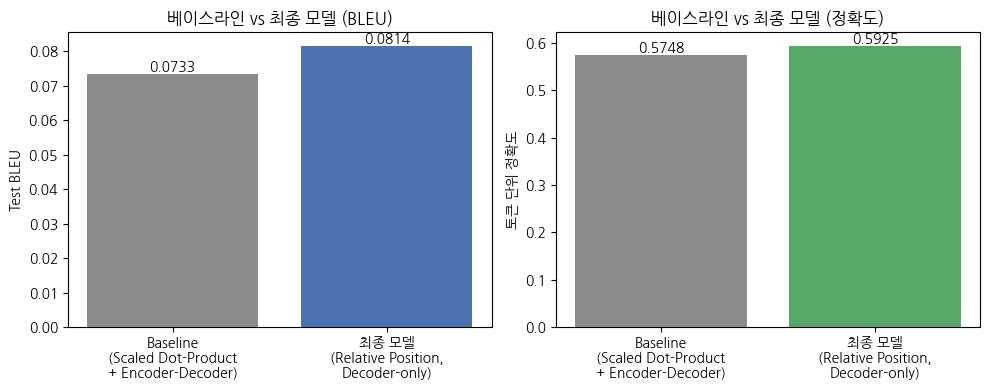

베이스라인 대비 최종 개선폭
Baseline Test BLEU     : 0.0733
최종 모델 Test BLEU     : 0.0814
BLEU 점수 차이         : +0.0081 (+11.0%)

Baseline 토큰 정확도    : 0.5748 (57.5%)
최종 모델 토큰 정확도    : 0.5925 (59.3%)
정확도 차이            : +0.0177 (+1.8%p)


In [ ]:
print("베이스라인(Scaled Dot-Product + Encoder-Decoder) 최종 훈련")
print(f"사용 하이퍼파라미터 -> n_layers={BEST_N_LAYERS}, d_model={BEST_D_MODEL}, d_ff={BEST_D_FF}, "
      f"dropout={BASELINE_DROPOUT} (베이스라인 자체 재확인 없음), warmup_steps={BASELINE_WARMUP}")

baseline_model, baseline_train_loss, baseline_val_loss, baseline_epochs, _, _ = build_and_train_attn(
    MultiHeadAttention, {}, epochs=CONFIG["max_epochs"], dropout=BASELINE_DROPOUT, warmup_steps=BASELINE_WARMUP, verbose=True
)

print(f"\n베이스라인 훈련 완료 - {baseline_epochs} 에폭 사용 / Train Loss: {baseline_train_loss:.4f} / Val Loss: {baseline_val_loss:.4f}")

# ---- 베이스라인 Test 평가 ----
baseline_test_metrics = score_responses(
    lambda s: translate_chat(s, baseline_model, word2idx, idx2word),
    evaluation_questions, evaluation_answers)
baseline_test_bleu = baseline_test_metrics['bleu']
baseline_test_accuracy = compute_accuracy(baseline_model, "encoder_decoder", evaluation_questions, evaluation_answers)
baseline_test_metrics['accuracy'] = baseline_test_accuracy
assert baseline_test_metrics['count'] == final_test_metrics['count'] == len(evaluation_questions)
comparison = pd.DataFrame([{'model': 'Baseline', **baseline_test_metrics},
                           {'model': 'Final', **final_test_metrics}])
display(comparison)
comparison.to_csv(artifact_dir / 'test_metrics.csv', index=False, encoding='utf-8-sig')

# ---- 최종 비교 차트 ----
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = ["Baseline\n(Scaled Dot-Product\n+ Encoder-Decoder)",
          "최종 모델\n(" + FINAL_ATTN_NAME + ",\n" + ("Encoder-Decoder" if FINAL_ARCH == "encoder_decoder" else "Decoder-only") + ")"]

bleu_values = [baseline_test_bleu, final_test_bleu]
axes[0].bar(labels, bleu_values, color=["#8C8C8C", "#4C72B0"])
axes[0].set_ylabel("Test BLEU")
axes[0].set_title("베이스라인 vs 최종 모델 (BLEU)")
for i, v in enumerate(bleu_values):
    axes[0].text(i, v, f"{v:.4f}", ha="center", va="bottom")

acc_values = [baseline_test_accuracy, final_test_accuracy]
axes[1].bar(labels, acc_values, color=["#8C8C8C", "#55A868"])
axes[1].set_ylabel("토큰 단위 정확도")
axes[1].set_title("베이스라인 vs 최종 모델 (정확도)")
for i, v in enumerate(acc_values):
    axes[1].text(i, v, f"{v:.4f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

print("=" * 50)
print("베이스라인 대비 최종 개선폭")
print("=" * 50)
print(f"Baseline Test BLEU     : {baseline_test_bleu:.4f}")
print(f"최종 모델 Test BLEU     : {final_test_bleu:.4f}")
bleu_improvement = final_test_bleu - baseline_test_bleu
print(f"BLEU 점수 차이         : {bleu_improvement:+.4f}"
      + (f" ({bleu_improvement / baseline_test_bleu * 100:+.1f}%)" if baseline_test_bleu > 0 else " (상대 변화율 계산 불가, Baseline BLEU = 0)"))
print()
print(f"Baseline 토큰 정확도    : {baseline_test_accuracy:.4f} ({baseline_test_accuracy * 100:.1f}%)")
print(f"최종 모델 토큰 정확도    : {final_test_accuracy:.4f} ({final_test_accuracy * 100:.1f}%)")
acc_improvement = final_test_accuracy - baseline_test_accuracy
print(f"정확도 차이            : {acc_improvement:+.4f} ({acc_improvement * 100:+.1f}%p)")

In [ ]:
print('마지막 확인:')
print(f'훈련데이터: {len(que_corpus):,}쌍 / 목표: {CONFIG["target_train_pairs"]:,}쌍')
print(f'복원한 최적 에폭: {chat_transformer.best_epoch} / 실제 실행 에폭: {epochs_trained}')
print(f'동일 Test 평가: {final_test_metrics["count"]}개 (빈 답변도 0점 포함)')

마지막 확인:
훈련데이터: 30,000쌍 / 목표: 30,000쌍
복원한 최적 에폭: 5 / 실제 실행 에폭: 10
동일 Test 평가: 1167개 (빈 답변도 0점 포함)


## 결론

6개 Attention·구조 조합 중 Val Loss가 가장 낮은 **Decoder-only + Relative Position**을 선택했다. 최종 설정은 레이어 2개, d_model=512, dropout=0.2, warmup=1000이며, 10에폭에 조기 종료된 학습에서 최적 시점인 **5에폭의 가중치**를 사용했다.

동일한 Test 1,167개에서 비교한 결과는 다음과 같다.

| 지표 | Baseline | 최종 모델 | 차이 |
|---|---|---|---|
| BLEU | 0.0733 | 0.0814 | 상대 +11.0% |
| 토큰 정확도(Teacher Forcing) | 57.5% | 59.3% | +1.8%p |
| 빈 답변 비율 | 0.0% | 0.0% | 변화 없음 |

이번 실험에서는 최종 모델의 BLEU와 토큰 정확도가 개선됐다.

다만 토큰 정확도는 정답의 앞부분을 제공한 상태에서의 예측 정확도이며, 적절한 답변을 생성한 비율은 아니다.

일부 질문에는 자연스럽게 답했지만, 문장 복원 오류와 질문에 맞지 않는 답변도 남았다.

또한 단일 시드 실험이고, 30,000쌍의 훈련데이터도 대화 표현을 덧붙이는 제한적인 증강으로 구성했으므로, 일반적인 성능 향상으로 단정하기는 어렵다.


## 회고
좀 더 의미있는 프로젝트를 만들기 위해 비교실험을 여러개 추가하였더니 처음으로 제시간에 프로젝트를 제출하지 못하는 상황이 되었다...하지만 전에 있던 프로젝트들은 본 프로젝트만큼 자세하게 실험을 하지 않았기 때문에 이번에 수행하면서 오히려 성취감은 더 올라갔다...소요시간과 성취감이 비례하긴 했는데..ㅎ..